In [4]:
from pathlib import Path

# This notebook is in: PROJECT_ROOT / "notebooks"
PROJECT_ROOT = Path.cwd().parent

DATA_DIR     = PROJECT_ROOT / "data"
MODEL_DIR    = PROJECT_ROOT / "models"
GRAPHICS_DIR = PROJECT_ROOT / "graphics"

MODEL_DIR.mkdir(exist_ok=True)
GRAPHICS_DIR.mkdir(exist_ok=True)

In [7]:
#Data Preprocessing
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", module="statsmodels")



DGS1 = pd.read_csv('../data/DGS1.csv')  
DGS2 = pd.read_csv('../data/DGS2.csv')
DGS5 = pd.read_csv('../data/DGS5.csv')
DGS10 = pd.read_csv('../data/DGS10.csv')    

print(DGS2.shape, DGS5.shape, DGS10.shape) #Print the shapes of the dataframes to verify successful loading
print(DGS2.info(),DGS5.info(), DGS10.info()) #Print the info of the dataframe to check data types and non-null counts

merged = DGS2.merge(DGS5, on="observation_date", how="inner").merge(DGS10, on="observation_date", how="inner") #Merge the dataframes on observation_date
merged = merged.dropna(subset=["DGS2","DGS5","DGS10"]) #Drop rows with missing values in any of the yield columns

merged = merged.set_index("observation_date") #Set observation_date as index
merged.index = pd.to_datetime(merged.index, errors="coerce") #Convert index to datetime

DGS1 = DGS1.dropna(subset=["DGS1"]) #Drop rows with missing values in any of the yield columns

DGS1 = DGS1.set_index("observation_date") #Set observation_date as index
DGS1.index = pd.to_datetime(DGS1.index, errors="coerce") #Convert index to datetime

viz_merged = merged.merge(DGS1, left_index=True, right_index=True, how="inner")


(4408, 2) (4408, 2) (4408, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4408 entries, 0 to 4407
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  4408 non-null   object 
 1   DGS2              4227 non-null   float64
dtypes: float64(1), object(1)
memory usage: 69.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4408 entries, 0 to 4407
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  4408 non-null   object 
 1   DGS5              4227 non-null   float64
dtypes: float64(1), object(1)
memory usage: 69.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4408 entries, 0 to 4407
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  4408 non-null   object 
 1   DGS10             4227 n

In [5]:
viz_merged.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4227 entries, 2009-01-02 to 2025-11-25
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DGS2    4227 non-null   float64
 1   DGS5    4227 non-null   float64
 2   DGS10   4227 non-null   float64
 3   DGS1    4227 non-null   float64
dtypes: float64(4)
memory usage: 165.1 KB


# Preprocessing summary

-Loaded raw FRED CSVs (DGS2.csv, DGS5.csv, DGS10.csv) and inspected shapes/dtypes. We saw 4408 entries of which 4227 were non-null

-Merged the three series on the common key observation_date using an inner join.

-Dropped rows with missing yields in any of DGS2, DGS5, DGS10 (missing days are typically U.S. market holidays or occasional gaps) leaving us with the 4227 entries from before

-Converted observation_date to proper datetime and set it as the index to enable clean time-series operations

# Vizualizing the Dataset

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Use visualization dataset with DGS1 included
data = viz_merged.dropna()

# Extract maturities (in years), matching the column order below
maturities = np.array([1, 2, 5, 10])

# Convert dates to numeric years
years = data.index.year + (data.index.dayofyear - 1) / 365

# Build surface arrays
X_mesh, Y_mesh = np.meshgrid(years, maturities)

# Z must follow the same order as 'maturities'
Z = data[["DGS1", "DGS2", "DGS5", "DGS10"]].T.values  # shape (4 maturities, N dates)

# Create plot
fig = go.Figure(data=[
    go.Surface(
        x=X_mesh,
        y=Y_mesh,
        z=Z,
        colorscale='Viridis',
        colorbar=dict(title='Yield (%)')
    )
])

fig.update_layout(
    title='U.S. Treasury Yield Curves (2009–2025)',
    scene=dict(
        xaxis_title='Year',
        yaxis_title='Maturity (years)',
        zaxis_title='Yield (%)'
    ),
    width=1200,
    height=900
)

fig.show()


# Descriptive Statistics

In [4]:
import pandas as pd
import numpy as np

# Use the visualization dataset including DGS1
yields = viz_merged[["DGS1", "DGS2", "DGS5", "DGS10"]].dropna()

# Build descriptive stats table including Median
desc = pd.DataFrame({
    "Mean":      yields.mean(),
    "Median":    yields.median(),
    "Std. dev.": yields.std(),
    "Min":       yields.min(),
    "Max":       yields.max(),
    "Skew":      yields.skew(),
    "Kurt":      yields.kurt()   # pandas: excess kurtosis (normal = 0)
})

# Rename index for readability
desc.index = ["1-year", "2-year", "5-year", "10-year"]

# Round for neat formatting
desc = desc.round(2)

print(desc)


         Mean  Median  Std. dev.   Min   Max  Skew  Kurt
1-year   1.45    0.49       1.70  0.04  5.49  1.11 -0.24
2-year   1.57    0.88       1.50  0.09  5.19  1.00 -0.43
5-year   2.06    1.75       1.16  0.19  4.95  0.64 -0.57
10-year  2.64    2.53       0.99  0.52  4.98  0.20 -0.66


# Define Train and Test Periods

In [8]:
idx = merged.index

# Proposed split dates
train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-25")  

# --- Check whether these dates exist in the index ---
print("Train start exists:", train_start in idx)
print("Train end exists:  ", train_end in idx)

print("Test start exists:", test_start in idx)
print("Test end exists:  ", test_end in idx)

train_days = ((idx >= train_start) & (idx <= train_end)).sum()
test_days  = ((idx >= test_start) & (idx <= test_end)).sum()

print("\nTRAINING DAYS:", train_days)
print("TEST DAYS:    ", test_days)


Train start exists: True
Train end exists:   True
Test start exists: True
Test end exists:   True

TRAINING DAYS: 2501
TEST DAYS:     1726


# Randomw Walk Benchmark

Random Walk performance (test period only):


RMSE  Mean_Error  Std_Error
Maturity Horizon                                 
DGS10    1        0.059004    0.000783   0.059016
         5        0.126819    0.004079   0.126790
         10       0.179402    0.008147   0.179269
         30       0.328191    0.024110   0.327401
DGS2     1        0.061250    0.000539   0.061266
         5        0.131312    0.002923   0.131318
         10       0.188868    0.005967   0.188828
         30       0.359041    0.017659   0.358713
DGS5     1        0.062598    0.000614   0.062613
         5        0.134188    0.003318   0.134186
         10       0.190236    0.006731   0.190172
         30       0.349621    0.019988   0.349152

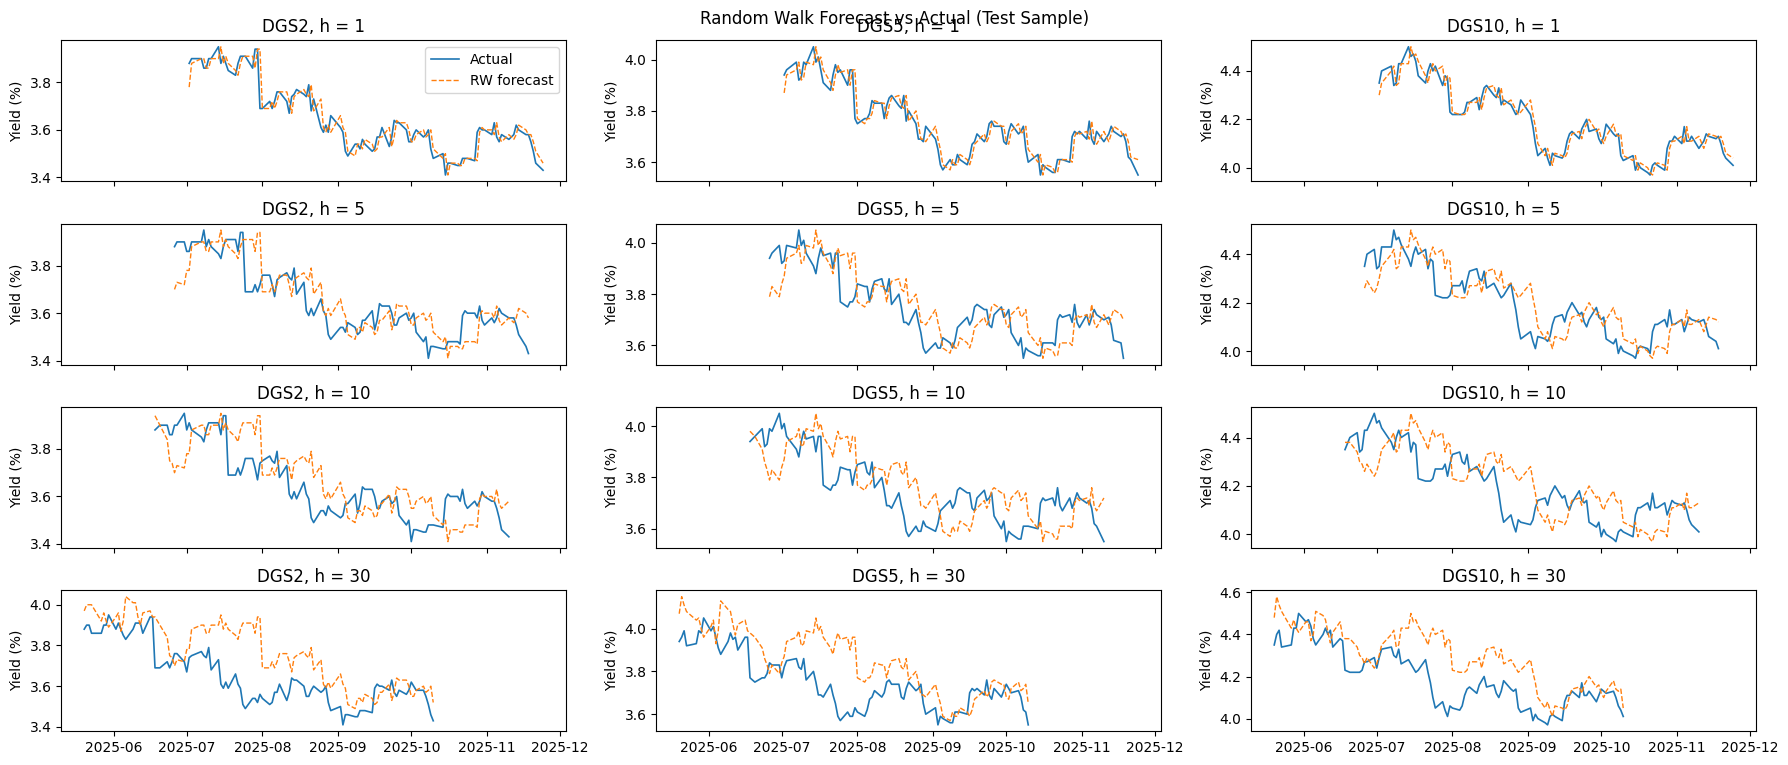

✔ Saved RW model to models/RW.pkl


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------Setting up date maturities, hoirzons and test period dates--------------
maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-25")

idx = merged.index

# -----------Setting up the Random Walk forecast-------------
results = []


rw_predictions = {}  # keys: (maturity, h) -> pd.Series
rw_actuals     = {}  # same shape as above

for col in maturity_cols:
    y = merged[col]

    for h in horizons:
        # Random walk: y_hat_{t+h|t} = y_t
        forecast = y.copy()
        actual   = y.shift(-h)  # align so index t has actual y_{t+h}

        # Restrict to test window
        mask_test = (idx >= test_start) & (idx <= test_end)
        actual_test = actual.loc[mask_test].dropna()

        # Align forecast with the same timestamps as actual_test
        forecast_test = forecast.loc[actual_test.index]

        # Forecast error: e_t = y_{t+h} - y_t
        errors = actual_test - forecast_test

        rmse = np.sqrt(np.mean(errors**2))
        mean_err = errors.mean()
        std_err = errors.std(ddof=1)

        results.append({
            "Maturity": col,
            "Horizon": h,
            "RMSE": rmse,
            "Mean_Error": mean_err,
            "Std_Error": std_err
        })

        rw_predictions[(col, h)] = forecast_test
        rw_actuals[(col, h)] = actual_test

# ------------ Here we store the results in a table ---------------
rw_results_df = pd.DataFrame(results)
rw_results_df = rw_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("Random Walk performance (test period only):")
display(rw_results_df)

# ------------------Create a visualization of the forecast and the real yield ------------------
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 8),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]

        actual_series = rw_actuals[(col, h)]
        pred_series   = rw_predictions[(col, h)]

        
        N = 100 # Set N to the amount of last observations we want to plot
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="RW forecast", linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Random Walk Forecast vs Actual (Test Sample)", y=0.95)
plt.tight_layout()
plt.show()


# --- Align naming convention for DM test ---
rw_pred_series = rw_predictions
rw_actual_series = rw_actuals


rw_bundle = {
    "predictions": rw_predictions,
    "actuals": rw_actuals,
    "metrics": rw_results_df
}

with open(MODEL_DIR / "RW.pkl", "wb") as f:
    pickle.dump(rw_bundle, f)

print("✔ Saved RW model to models/RW.pkl")

Our results are as expected.

-Increasing Maturity reduces the RMSE -> more persistence in longer yields

-Increasing forecast horizons increases the RMSE -> more volatility over long periods

-Maturities are ordered DGS2 > DGS 5 > DGS 10 -> longer yields, more persistence

# Implement the Dynamic Nelson Siegel Model

[SANITY] DNS cross-sectional reconstruction RMSE (all sample, all maturities): 0.000000

=== Running DNS VAR(1) forecasts for horizon h = 1 ===


c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_m


=== Running DNS VAR(1) forecasts for horizon h = 5 ===


c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_m


=== Running DNS VAR(1) forecasts for horizon h = 10 ===


...


=== Running DNS VAR(1) forecasts for horizon h = 30 ===


c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_m


=== Safety log (first 5 forecasts per horizon) ===

Horizon h = 1:
  origin: 2019-01-02, forecast: 2019-01-03, train_size: 2502
  origin: 2019-01-03, forecast: 2019-01-04, train_size: 2503
  origin: 2019-01-04, forecast: 2019-01-07, train_size: 2504
  origin: 2019-01-07, forecast: 2019-01-08, train_size: 2505
  origin: 2019-01-08, forecast: 2019-01-09, train_size: 2506

Horizon h = 5:
  origin: 2019-01-02, forecast: 2019-01-09, train_size: 2502
  origin: 2019-01-03, forecast: 2019-01-10, train_size: 2503
  origin: 2019-01-04, forecast: 2019-01-11, train_size: 2504
  origin: 2019-01-07, forecast: 2019-01-14, train_size: 2505
  origin: 2019-01-08, forecast: 2019-01-15, train_size: 2506

Horizon h = 10:
  origin: 2019-01-02, forecast: 2019-01-16, train_size: 2502
  origin: 2019-01-03, forecast: 2019-01-17, train_size: 2503
  origin: 2019-01-04, forecast: 2019-01-18, train_size: 2504
  origin: 2019-01-07, forecast: 2019-01-22, train_size: 2505
  origin: 2019-01-08, forecast: 2019-01-23, t

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_m

RMSE  Mean_Error  Std_Error  N_Forecasts
Maturity Horizon                                              
DGS10    1        0.059081    0.000113   0.059098         1725
         5        0.127669    0.000720   0.127704         1721
         10       0.181670    0.001404   0.181718         1716
         30       0.338187    0.003590   0.338268         1696
DGS2     1        0.061312   -0.000139   0.061329         1725
         5        0.131994   -0.000475   0.132031         1721
         10       0.190579   -0.000846   0.190632         1716
         30       0.366263   -0.003018   0.366359         1696
DGS5     1        0.062685    0.000124   0.062703         1725
         5        0.135193    0.000850   0.135230         1721
         10       0.192971    0.001753   0.193019         1716
         30       0.361938    0.004555   0.362016         1696

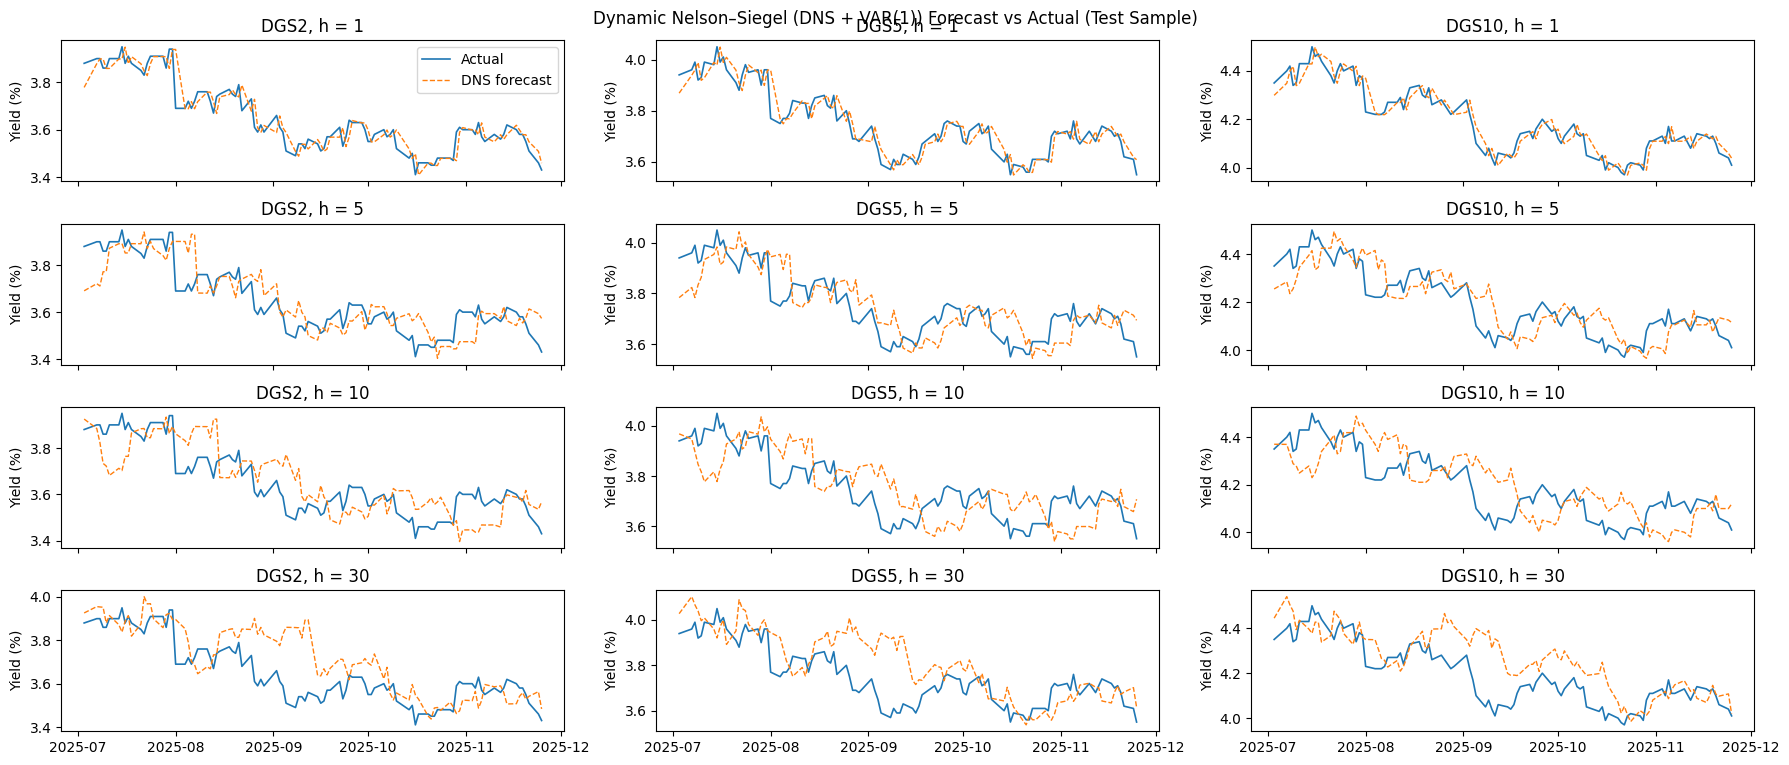

✔ Saved DNS model to c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\models\DNS.pkl


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR


# Prepare settings, Fixed Lambda
maturity_cols = ["DGS2", "DGS5", "DGS10"]
tau_years = np.array([2.0, 5.0, 10.0])  # maturities in years
lmbda = 0.0609

train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-25")

horizons = [1, 5, 10, 30]


merged = merged.sort_index()
idx = merged.index
idx_array = np.array(idx)

# Quick sanity checks on dates
assert idx[0] <= train_start, "Train start before first data point"
assert idx[-1] >= test_end, "Test end after last data point in merged"

# ------------------- Extract DNS factors from yields -------------
def dns_loadings(tau, lam):
    tau = np.asarray(tau, dtype=float)
    one = np.ones_like(tau)
    term = (1 - np.exp(-lam * tau)) / (lam * tau)
    f1 = one
    f2 = term
    f3 = term - np.exp(-lam * tau)
    X = np.column_stack([f1, f2, f3])  # shape (n_maturities, 3)
    return X

# Cross-sectional loading matrix X (constant)
X = dns_loadings(tau_years, lmbda)  # shape (3, 3)

# DNS pseudo-inverse to map yields -> betas
XtX = X.T @ X
assert np.linalg.matrix_rank(XtX) == 3, "X'X is not full rank, DNS inversion fails"

B = np.linalg.inv(XtX) @ X.T  # shape (3, 3)

# Extract betas_t from yields_t (cross-sectional regression at each t)
y_mat = merged[maturity_cols].values  # shape (T, 3)
betas = (y_mat @ B.T)                 # shape (T, 3)

betas_df = pd.DataFrame(
    betas,
    index=merged.index,
    columns=["beta1", "beta2", "beta3"]
)

# Optional internal reconstruction sanity check (no forecasting yet)
y_recon = (betas @ X.T)  # T x 3
recon_rmse = np.sqrt(np.mean((y_mat - y_recon)**2))
print(f"[SANITY] DNS cross-sectional reconstruction RMSE (all sample, all maturities): {recon_rmse:.6f}")

# ------------------- Set up test positions -------------
test_mask = (idx_array >= test_start) & (idx_array <= test_end)
test_positions = np.where(test_mask)[0]
assert len(test_positions) > 0, "No test positions found between test_start and test_end"

last_test_pos = test_positions[-1]

# ------------------- Expanding-window VAR(1) forecasts for betas -------------
dns_pred = {(col, h): {} for col in maturity_cols for h in horizons}

# For safety logging
safety_log = {h: [] for h in horizons}

for h in horizons:
    print(f"\n=== Running DNS VAR(1) forecasts for horizon h = {h} ===")
    
    prev_train_size = 0
    prev_forecast_pos = None

    for pos in test_positions:
        origin_date = idx_array[pos]
        forecast_pos = pos + h

        # If we do not have y_{t+h} inside test window, skip
        if forecast_pos > last_test_pos:
            continue
        
        forecast_date = idx_array[forecast_pos]

       #------------------------- Construct expanding window -------------------------
        train_mask = (idx_array >= train_start) & (idx_array <= origin_date)
        train_betas = betas_df.loc[train_mask]
        train_size = len(train_betas)

        # Harsh safety checks on training window
        assert train_size > 0, "Empty training window, something is wrong"
        assert train_betas.index.min() >= train_start, "Training starts before train_start"
        assert train_betas.index.max() == origin_date, "Training does not end at origin date"
        assert all(train_betas.index <= origin_date), "Training contains observations after origin date (look ahead)"
        assert train_size >= prev_train_size, "Training window is not expanding monotonically"
        prev_train_size = train_size

        # Safety: forecast date must be strictly after origin date
        assert forecast_date > origin_date, "Forecast date is not strictly after origin date"

        # Safety: forecast date must be in test window
        assert (forecast_date >= test_start) and (forecast_date <= test_end), \
            f"Forecast date {forecast_date} outside test window"

        # Safety: monotonic forecast positions
        if prev_forecast_pos is not None:
            assert forecast_pos > prev_forecast_pos, "Forecast positions not strictly increasing"
        prev_forecast_pos = forecast_pos

        # ------------------------- Fit VAR(1) and forecast betas -------------------------
        var_model = VAR(train_betas)
        var_res = var_model.fit(maxlags=1)

        # Safety: we really fitted VAR(1)
        assert var_res.k_ar == 1, f"Expected VAR(1), got VAR({var_res.k_ar})"

        lag_order = var_res.k_ar
        beta_hist = train_betas.values[-lag_order:]  # last k_ar observations

        # h-step-ahead forecast path
        beta_forecast_path = var_res.forecast(beta_hist, steps=h)
        assert beta_forecast_path.shape == (h, 3), "Unexpected beta forecast shape"

        beta_forecast_h = beta_forecast_path[-1]  # horizon-h forecast

        # Map betas back into yields
        y_hat_vec = X @ beta_forecast_h  # length 3

        # Save predictions per maturity
        for j, col in enumerate(maturity_cols):
            dns_pred[(col, h)][forecast_date] = y_hat_vec[j]

        # Log first few entries for manual inspection
        if len(safety_log[h]) < 5:
            safety_log[h].append({
                "origin_date": pd.Timestamp(origin_date),
                "forecast_date": pd.Timestamp(forecast_date),
                "train_size": train_size
            })

# Show safety sample
print("\n=== Safety log (first 5 forecasts per horizon) ===")
for h in horizons:
    print(f"\nHorizon h = {h}:")
    if len(safety_log[h]) == 0:
        print("  (no entries logged)")
    else:
        for entry in safety_log[h]:
            print(
                f"  origin: {entry['origin_date'].date()}, "
                f"forecast: {entry['forecast_date'].date()}, "
                f"train_size: {entry['train_size']}"
            )

# -------------------------- Convert predictions to series and align with actuals -------------------------
dns_pred_series = {}
dns_actual_series = {}

for (col, h), pred_dict in dns_pred.items():
    if len(pred_dict) == 0:
        continue

    pred_s = pd.Series(pred_dict).sort_index()
    # Actual yields at the forecast dates
    actual_s = merged[col].loc[pred_s.index]

    # Safety: indices must match exactly
    assert pred_s.index.equals(actual_s.index), "Predictions and actuals indices do not match"
    # Safety: all dates inside test window
    assert all((pred_s.index >= test_start) & (pred_s.index <= test_end)), \
        "Prediction indices outside test window"

    # Safety: earliest prediction must not be before training start
    assert pred_s.index.min() > train_start, "Earliest prediction before training start"

    dns_pred_series[(col, h)] = pred_s
    dns_actual_series[(col, h)] = actual_s

# -------------------------- Evaluate DNS (VAR(1)) forecasts -------------------------
results = []

for (col, h), pred_s in dns_pred_series.items():
    actual_s = dns_actual_series[(col, h)]
    errors = actual_s - pred_s

    rmse = np.sqrt(np.mean(errors**2))
    mean_err = errors.mean()
    std_err = errors.std(ddof=1)

    results.append({
        "Maturity": col,
        "Horizon": h,
        "RMSE": rmse,
        "Mean_Error": mean_err,
        "Std_Error": std_err,
        "N_Forecasts": len(errors)
    })

dns_results_df = pd.DataFrame(results)
dns_results_df = dns_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("\nDNS (VAR(1)) performance (test period):")
display(dns_results_df)

# ------------------Create a visualization of the DNS (VAR(1)) forecast and the real yield ------------------
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 8),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]

        key = (col, h)
        if key not in dns_pred_series:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = dns_actual_series[key]
        pred_series   = dns_pred_series[key]

        # Optional: zoom into last N observations
        N = 100
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="DNS forecast", linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Dynamic Nelson–Siegel (DNS + VAR(1)) Forecast vs Actual (Test Sample)", y=0.95)
plt.tight_layout()
plt.show()


# ======================= SAVE DNS MODEL =======================

dns_bundle = {
    "predictions": dns_pred_series,    # dict[(maturity, h)] -> Series
    "actuals": dns_actual_series,      # same keys as predictions
    "metrics": dns_results_df          # RMSE etc.
}

with open(MODEL_DIR / "DNS.pkl", "wb") as f:
    pickle.dump(dns_bundle, f)

print(f"✔ Saved DNS model to {MODEL_DIR / 'DNS.pkl'}")


Our results are as expected

-DNS underperforms RW over all maturities and horizons. RW is very hard to beat for so short lived periods

-But the difference is very small meaning the DNS model seems to captures important information

-DNS is just a "sophisticated" RW model 

# Build the Ridge Model

# Search best set of hyperparameters alpha and p (ONLY RUN THIS ONCE AND THEN SAVE PARAMTERS)

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.linear_model import Ridge
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.base import clone

# # =====================================================
# # 0. Settings
# # =====================================================
# maturity_cols = ["DGS2", "DGS5", "DGS10"]
# horizons = [1, 5, 10, 30]

# train_start = pd.Timestamp("2009-01-02")
# train_end   = pd.Timestamp("2018-12-31")

# # Inner "CV validation" period (within training sample)
# cv_test_start = pd.Timestamp("2014-01-02")  # last ~5 years of train
# cv_test_end   = train_end

# min_train_size = 252  # at least ~1y of data to fit

# merged = merged.sort_index()
# idx = merged.index

# # =====================================================
# # 1. Hyperparameter grids
# # =====================================================
# alpha_grid = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
# p_grid     = [1, 3, 5, 10]   # lag length candidates

# print("Alpha grid:", alpha_grid)
# print("Lag grid (p):", p_grid)

# # =====================================================
# # 2. Helper: build lagged dataset for given target/horizon/p
# #     - Features: yields + spreads + curvature with lags
# #     - Target:   Δy_{t+h} = y_{t+h} - y_t  (yield change)
# # =====================================================
# def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
#     """
#     Features:
#         - Yields of all maturities with lags 0..max_lag
#         - Spreads and curvature (linear combos of yields) with lags 0..max_lag
#           * spread_5_2  = DGS5  - DGS2
#           * spread_10_2 = DGS10 - DGS2
#           * curv_5      = 2*DGS5 - DGS2 - DGS10

#     Target:
#         - Yield change Δy_{t+h} = y_{t+h} - y_t for target_col

#     Index:
#         - origin dates t (information set at time t)
#     """
#     # Base yields
#     base = merged[maturity_cols].copy()

#     # Spreads and curvature (no new info, just linear transformations)
#     base["spread_5_2"]  = base["DGS5"]  - base["DGS2"]
#     base["spread_10_2"] = base["DGS10"] - base["DGS2"]
#     base["curv_5"]      = 2 * base["DGS5"] - base["DGS2"] - base["DGS10"]

#     cols_for_lags = maturity_cols + ["spread_5_2", "spread_10_2", "curv_5"]

#     # Start empty df with same index
#     df = pd.DataFrame(index=merged.index)

#     # Add lagged features for all base cols
#     for col in cols_for_lags:
#         for lag in range(0, max_lag + 1):
#             df[f"{col}_lag{lag}"] = base[col].shift(lag)

#     # Target: yield change Δy_{t+h} = y_{t+h} - y_t
#     df["target_delta"] = merged[target_col].shift(-horizon) - merged[target_col]

#     # Drop rows with NaNs (from lags and shifting)
#     df = df.dropna()

#     # All columns except the target are features
#     feature_cols = [c for c in df.columns if c != "target_delta"]

#     X = df[feature_cols].values
#     y = df["target_delta"].values
#     dates = df.index  # origin dates t

#     return X, y, dates

# # =====================================================
# # 3. Helper: expanding-window Ridge for CV (NO look-ahead)
# #     - Trains on Δy targets
# #     - Reconstructs level forecasts: y_hat_{t+h|t} = y_t + Δy_hat
# #     - Returns series of LEVEL forecasts and LEVEL actuals
# # =====================================================
# def expanding_window_ridge_consistent(
#     X, y, dates, horizon,
#     train_start, test_start, test_end,
#     base_model, target_series,
#     min_train_size=252
# ):
#     """
#     Expanding-window Ridge used for CV, with NO look-ahead.

#     - Supervised rows (X, y) are indexed by origin date t in `dates`.
#     - Each row uses features at t and target Δy_{t+h} = y_{t+h} - y_t.
#     - At a forecast origin t0 in [test_start, test_end], we may only train on
#         rows with t <= t0 - h,
#       so that all targets y_{t+h} in the training set are in the past
#       relative to t0 (no look-ahead).
#     - For each origin t0, we:
#         * predict Δy_hat_{t+h}
#         * reconstruct level forecast: y_hat_{t+h|t0} = y_t0 + Δy_hat_{t+h}
#       and store it at index forecast_date = t0 + h.
#     - Returns:
#         pred_s   = series of LEVEL forecasts y_hat_{t+h|t}
#         actual_s = series of LEVEL actuals   y_{t+h}
#     """
#     dates = pd.DatetimeIndex(dates)

#     # Map dataset dates -> row index in X, y
#     ds_idx_map = {d: i for i, d in enumerate(dates)}

#     idx = merged.index
#     idx_array = np.array(idx)

#     # origin dates t0 in CV window
#     test_mask = (idx_array >= test_start) & (idx_array <= test_end)
#     test_positions = np.where(test_mask)[0]
#     if len(test_positions) == 0:
#         return None, None

#     last_pos = len(idx) - 1
#     last_test_pos = test_positions[-1]

#     pred_dict = {}
#     debug_count = 0  # limit debug prints

#     for pos in test_positions:
#         origin_date = idx[pos]  # t0

#         # need at least h days of history to define t0 - h
#         if pos - horizon < 0:
#             continue

#         # calendar date t0 - h (h index steps back)
#         train_end_date = idx[pos - horizon]

#         # origin date must be present in supervised dataset
#         if origin_date not in ds_idx_map:
#             continue

#         # forecast date t0 + h
#         forecast_pos = pos + horizon
#         if forecast_pos > last_test_pos or forecast_pos > last_pos:
#             continue
#         forecast_date = idx[forecast_pos]

#         # training rows: t in [train_start, t0 - h]
#         train_mask_ds = (dates >= train_start) & (dates <= train_end_date)
#         train_idx_ds = np.where(train_mask_ds)[0]

#         if len(train_idx_ds) < min_train_size:
#             continue

#         X_train, y_train = X[train_idx_ds], y[train_idx_ds]

#         origin_row = ds_idx_map[origin_date]
#         X_origin = X[origin_row:origin_row+1]

#         # DEBUG: print a few origins to verify no look-ahead
#         if debug_count < 5:
#             debug_count += 1
#             print(
#                 f"[DEBUG RIDGE CV] origin={origin_date.date()}, "
#                 f"train_end_date(t0-h)={train_end_date.date()}, "
#                 f"max_train_t={dates[train_idx_ds].max().date()}, "
#                 f"forecast_date(t0+h)={forecast_date.date()}"
#             )
#             # safety check: latest training t must be <= t0 - h
#             assert dates[train_idx_ds].max() <= train_end_date, \
#                 "DATA LEAK (Ridge CV): training uses dates after t0 - h!"

#         model = clone(base_model)
#         model.fit(X_train, y_train)
#         delta_hat = model.predict(X_origin)[0]   # predicted Δy_{t+h}

#         # reconstruct LEVEL forecast: y_hat_{t+h|t0} = y_t0 + Δy_hat_{t+h}
#         y_level_t0 = target_series.loc[origin_date]
#         y_hat_level = y_level_t0 + delta_hat

#         pred_dict[forecast_date] = y_hat_level

#     if len(pred_dict) == 0:
#         return None, None

#     pred_s = pd.Series(pred_dict).sort_index()
#     # Actual LEVEL yields at the forecast dates
#     actual_s = target_series.loc[pred_s.index]

#     return pred_s, actual_s

# # =====================================================
# # 4. Time-series CV over alpha and p (inside training period)
# # =====================================================
# cv_rows = []

# for target_col in maturity_cols:
#     # Full LEVEL series for this maturity (used to reconstruct y_hat and compare)
#     target_series_full = merged[target_col]

#     for h in horizons:
#         print(f"\n=== CV for Ridge (Δy target): target={target_col}, h={h} ===")

#         for p in p_grid:
#             X, y, dates = build_lagged_dataset(
#                 merged=merged,
#                 maturity_cols=maturity_cols,
#                 target_col=target_col,
#                 horizon=h,
#                 max_lag=p
#             )

#             # Restrict dataset to dates <= train_end (no peek into OOS)
#             mask_in_train = dates <= train_end
#             X_train_ds = X[mask_in_train]
#             y_train_ds = y[mask_in_train]
#             dates_train_ds = dates[mask_in_train]

#             if len(dates_train_ds) < min_train_size + 50:
#                 print(f"  Skipping p={p}: not enough data.")
#                 continue

#             for alpha in alpha_grid:
#                 ridge_pipeline = Pipeline([
#                     ("scaler", StandardScaler(with_mean=False)),
#                     ("ridge", Ridge(alpha=alpha))
#                 ])

#                 # Expanding-window CV within [cv_test_start .. cv_test_end]
#                 pred_s, actual_s = expanding_window_ridge_consistent(
#                     X=X_train_ds,
#                     y=y_train_ds,
#                     dates=dates_train_ds,
#                     horizon=h,
#                     train_start=train_start,
#                     test_start=cv_test_start,
#                     test_end=cv_test_end,
#                     base_model=ridge_pipeline,
#                     target_series=target_series_full,
#                     min_train_size=min_train_size
#                 )

#                 if pred_s is None:
#                     print(f"  (alpha={alpha}, p={p}) produced no forecasts.")
#                     continue

#                 # errors in LEVEL space: y_{t+h} - y_hat_{t+h|t}
#                 errors = actual_s - pred_s
#                 rmse = np.sqrt(np.mean(errors**2))

#                 cv_rows.append({
#                     "Maturity": target_col,
#                     "Horizon": h,
#                     "alpha": alpha,
#                     "p": p,
#                     "CV_RMSE": rmse,
#                     "N_Forecasts": len(errors)
#                 })

# ridge_cv_results = pd.DataFrame(cv_rows)
# ridge_cv_results = ridge_cv_results.set_index(["Maturity", "Horizon"]).sort_index()

# print("\nRidge CV results (Δy target, evaluated on levels; first rows):")
# display(ridge_cv_results.head())

# # =====================================================
# # 5. Choose best (alpha, p) per (Maturity, Horizon)
# # =====================================================
# ridge_best_params = {}

# for (mat, h), group in ridge_cv_results.groupby(level=[0, 1]):
#     best_row = group.sort_values("CV_RMSE").iloc[0]
#     ridge_best_params[(mat, h)] = {
#         "alpha": best_row["alpha"],
#         "p": int(best_row["p"]),
#         "CV_RMSE": best_row["CV_RMSE"],
#         "N_Forecasts": int(best_row["N_Forecasts"])
#     }

# print("\nBest Ridge hyperparameters per (Maturity, Horizon) [Δy target]:")
# for key, val in ridge_best_params.items():
#     mat, h = key
#     print(
#         f"  {mat}, h={h}: alpha={val['alpha']}, p={val['p']}, "
#         f"CV_RMSE={val['CV_RMSE']:.6f}, N={val['N_Forecasts']}"
#     )


Alpha grid: [0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
Lag grid (p): [1, 3, 5, 10]

=== CV for Ridge: target=DGS2, h=1 ===
[DEBUG RIDGE CV] origin=2014-01-02, train_end_date(t0-h)=2013-12-31, max_train_t=2013-12-31, forecast_date(t0+h)=2014-01-03
[DEBUG RIDGE CV] origin=2014-01-03, train_end_date(t0-h)=2014-01-02, max_train_t=2014-01-02, forecast_date(t0+h)=2014-01-06
[DEBUG RIDGE CV] origin=2014-01-06, train_end_date(t0-h)=2014-01-03, max_train_t=2014-01-03, forecast_date(t0+h)=2014-01-07
[DEBUG RIDGE CV] origin=2014-01-07, train_end_date(t0-h)=2014-01-06, max_train_t=2014-01-06, forecast_date(t0+h)=2014-01-08
[DEBUG RIDGE CV] origin=2014-01-08, train_end_date(t0-h)=2014-01-07, max_train_t=2014-01-07, forecast_date(t0+h)=2014-01-09
[DEBUG RIDGE CV] origin=2014-01-02, train_end_date(t0-h)=2013-12-31, max_train_t=2013-12-31, forecast_date(t0+h)=2014-01-03
[DEBUG RIDGE CV] origin=2014-01-03, train_end_date(t0-h)=2014-01-02, max_train_t=2014-01-02, forecast_date(t0+h)=2014-01-06
[DEBUG RIDGE CV] or

alpha  p   CV_RMSE  N_Forecasts
Maturity Horizon                                 
DGS10    1         0.05  1  0.042203         1249
         1         0.10  1  0.042208         1249
         1         0.15  1  0.042214         1249
         1         0.20  1  0.042221         1249
         1         0.30  1  0.042238         1249


Best Ridge hyperparameters per (Maturity, Horizon):
  DGS10, h=1: alpha=0.05, p=1, CV_RMSE=0.042203, N=1249
  DGS10, h=5: alpha=0.1, p=1, CV_RMSE=0.091810, N=1245
  DGS10, h=10: alpha=0.05, p=1, CV_RMSE=0.127730, N=1240
  DGS10, h=30: alpha=0.4, p=10, CV_RMSE=0.218936, N=1220
  DGS2, h=1: alpha=0.05, p=1, CV_RMSE=0.029417, N=1249
  DGS2, h=5: alpha=0.05, p=1, CV_RMSE=0.061222, N=1245
  DGS2, h=10: alpha=0.4, p=1, CV_RMSE=0.086094, N=1240
  DGS2, h=30: alpha=0.4, p=1, CV_RMSE=0.141045, N=1220
  DGS5, h=1: alpha=0.05, p=1, CV_RMSE=0.041442, N=1249
  DGS5, h=5: alpha=0.15, p=1, CV_RMSE=0.091203, N=1245
  DGS5, h=10: alpha=0.05, p=1, CV_RMSE=0.127605, N=1240
  DGS5, h=30: alpha=0.4, p=1, CV_RMSE=0.213164, N=1220


## Saving best paramters to save time

In [11]:
ridge_best_params = {
    ("DGS10", 1):  {"alpha": 0.05, "p": 1},
    ("DGS10", 5):  {"alpha": 0.10, "p": 1},
    ("DGS10", 10): {"alpha": 0.05, "p": 1},
    ("DGS10", 30): {"alpha": 0.40, "p": 10},

    ("DGS2", 1):   {"alpha": 0.05, "p": 1},
    ("DGS2", 5):   {"alpha": 0.05, "p": 1},
    ("DGS2", 10):  {"alpha": 0.40, "p": 1},
    ("DGS2", 30):  {"alpha": 0.40, "p": 1},

    ("DGS5", 1):   {"alpha": 0.05, "p": 1},
    ("DGS5", 5):   {"alpha": 0.15, "p": 1},
    ("DGS5", 10):  {"alpha": 0.05, "p": 1},
    ("DGS5", 30):  {"alpha": 0.40, "p": 1}
}


# Train Ridge on best set of hyperparameters

Running Ridge forecasts for DGS2, h = 1, alpha=0.05, p=1 ...
[DEBUG RIDGE Δy] origin=2019-01-02, train_end_date(t0-h)=2018-12-31, max_train_t=2018-12-31, forecast_date(t0+h)=2019-01-03
[DEBUG RIDGE Δy] origin=2019-01-03, train_end_date(t0-h)=2019-01-02, max_train_t=2019-01-02, forecast_date(t0+h)=2019-01-04
[DEBUG RIDGE Δy] origin=2019-01-04, train_end_date(t0-h)=2019-01-03, max_train_t=2019-01-03, forecast_date(t0+h)=2019-01-07
[DEBUG RIDGE Δy] origin=2019-01-07, train_end_date(t0-h)=2019-01-04, max_train_t=2019-01-04, forecast_date(t0+h)=2019-01-08
[DEBUG RIDGE Δy] origin=2019-01-08, train_end_date(t0-h)=2019-01-07, max_train_t=2019-01-07, forecast_date(t0+h)=2019-01-09
Running Ridge forecasts for DGS2, h = 5, alpha=0.05, p=1 ...
[DEBUG RIDGE Δy] origin=2019-01-02, train_end_date(t0-h)=2018-12-24, max_train_t=2018-12-24, forecast_date(t0+h)=2019-01-09
[DEBUG RIDGE Δy] origin=2019-01-03, train_end_date(t0-h)=2018-12-26, max_train_t=2018-12-26, forecast_date(t0+h)=2019-01-10
[DEBUG RID

RMSE  Mean_Error  Std_Error  N_Forecasts  alpha   p
Maturity Horizon                                                         
DGS10    1        0.059137    0.000129   0.059154         1725   0.05   1
         5        0.127458    0.000717   0.127493         1721   0.10   1
         10       0.181782    0.001902   0.181825         1716   0.05   1
         30       0.346037    0.004862   0.346105         1696   0.40  10
DGS2     1        0.061421   -0.000223   0.061438         1725   0.05   1
         5        0.132197   -0.001216   0.132230         1721   0.05   1
         10       0.190964   -0.001974   0.191009         1716   0.40   1
         30       0.369247   -0.001112   0.369354         1696   0.40   1
DGS5     1        0.062806    0.000216   0.062824         1725   0.05   1
         5        0.135146    0.001102   0.135181         1721   0.15   1
         10       0.193134    0.002601   0.193173         1716   0.05   1
         30       0.364119    0.009560   0.364101         1696   0.40   1

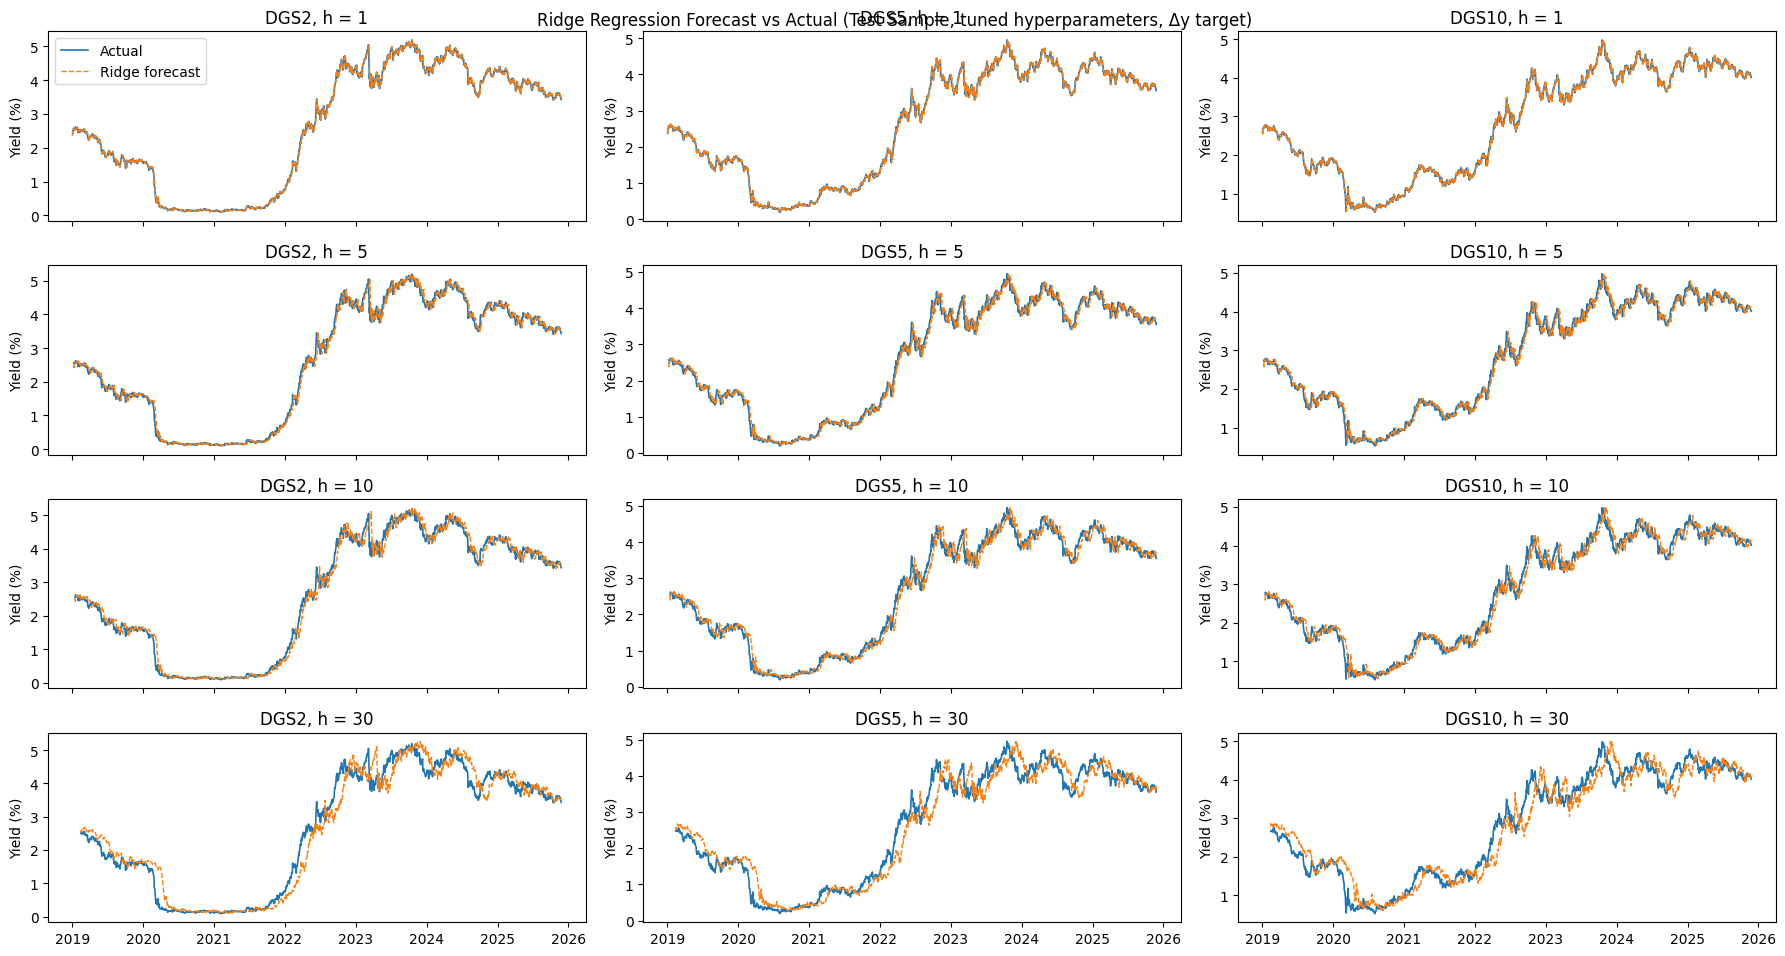

✔ Saved Ridge model to c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\models\Ridge.pkl


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# =====================================================
# 0. Settings
# =====================================================
maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-25")

min_train_size = 252  # require at least ~1 year of data to fit

merged = merged.sort_index()
idx = merged.index
idx_array = np.array(idx)

# =====================================================
# 1. Supervised dataset builder (lags + horizon, Δy target)
# =====================================================
def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
    """
    Creates a supervised dataset for a given target maturity and horizon.

    Features (information set at time t):
        - Yields of all maturities with lags 0..max_lag
        - Spreads and curvature (linear combos of yields) with lags 0..max_lag
          * spread_5_2  = DGS5  - DGS2
          * spread_10_2 = DGS10 - DGS2
          * curv_5      = 2*DGS5 - DGS2 - DGS10

    Target:
        - Yield change Δy_{t+h} = y_{t+h} - y_t for target_col

    Index:
        - origin dates t (the date we observe the information set)
    """
    # Base yields
    base = merged[maturity_cols].copy()

    # Spreads and curvature (no new info, just linear combinations)
    base["spread_5_2"]  = base["DGS5"]  - base["DGS2"]
    base["spread_10_2"] = base["DGS10"] - base["DGS2"]
    base["curv_5"]      = 2 * base["DGS5"] - base["DGS2"] - base["DGS10"]

    cols_for_lags = maturity_cols + ["spread_5_2", "spread_10_2", "curv_5"]

    # Start empty df with same index
    df = pd.DataFrame(index=merged.index)

    # Add lagged features for all base cols
    for col in cols_for_lags:
        for lag in range(0, max_lag + 1):
            df[f"{col}_lag{lag}"] = base[col].shift(lag)

    # Target: yield change Δy_{t+h} = y_{t+h} - y_t
    df["target_delta"] = merged[target_col].shift(-horizon) - merged[target_col]

    # Drop rows with NaNs (from lags and shifting)
    df = df.dropna()

    # All columns except the target are features
    feature_cols = [c for c in df.columns if c != "target_delta"]

    X = df[feature_cols].values
    y = df["target_delta"].values
    dates = df.index  # origin dates t

    return X, y, dates

# =====================================================
# 2. Expanding window forecasting function (Δy target, returns LEVEL forecasts)
# =====================================================
def expanding_window_ridge(
    X, y, dates, horizon,
    train_start, test_start, test_end,
    base_model, target_series,
    min_train_size=252
):
    """
    Expanding-window Ridge with NO look-ahead, using Δy targets.

    Supervised rows (X, y) are indexed by origin date t in `dates`.
    Each row uses features at t and target
        Δy_{t+h} = y_{t+h} - y_t
    (because of shift(-horizon) in the dataset builder).

    At a forecast origin t0 (calendar date), we may only train on rows
    with t <= t0 - h, so that all targets y_{t+h} in the training set
    are in the past relative to t0.

    For each origin t0 in [test_start, test_end]:
        - predict Δy_hat_{t0+h|t0}
        - reconstruct level forecast:
            y_hat_{t0+h|t0} = y_t0 + Δy_hat_{t0+h|t0}
        - store this forecast at index forecast_date = t0 + h.

    Returns:
        pred_s   : series of LEVEL forecasts y_hat_{t+h|t}
        actual_s : series of LEVEL actuals   y_{t+h}
    """
    dates = pd.DatetimeIndex(dates)

    # Map origin dates in supervised dataset -> row indices
    ds_idx_map = {d: i for i, d in enumerate(dates)}

    idx = merged.index
    idx_array = np.array(idx)

    # Origin dates t0 in the test window
    test_mask = (idx_array >= test_start) & (idx_array <= test_end)
    test_positions = np.where(test_mask)[0]
    if len(test_positions) == 0:
        return None, None

    last_pos = len(idx) - 1
    last_test_pos = test_positions[-1]

    pred_dict = {}
    debug_count = 0  # limit debug prints

    for pos in test_positions:
        origin_date = idx[pos]  # t0

        # Need at least 'horizon' days of history to define t0 - h
        if pos - horizon < 0:
            continue

        # Calendar date t0 - h (h index steps back)
        train_end_date = idx[pos - horizon]

        # origin date must be present in supervised dataset
        if origin_date not in ds_idx_map:
            continue

        # Forecast date t0 + h
        forecast_pos = pos + horizon
        if forecast_pos > last_test_pos or forecast_pos > last_pos:
            # drop last h-1 origins so that t0 + h stays in test window
            continue

        forecast_date = idx[forecast_pos]

        # Training rows: t in [train_start, t0 - h]
        train_mask_ds = (dates >= train_start) & (dates <= train_end_date)
        train_idx_ds = np.where(train_mask_ds)[0]

        if len(train_idx_ds) < min_train_size:
            continue

        X_train, y_train = X[train_idx_ds], y[train_idx_ds]

        origin_row = ds_idx_map[origin_date]
        X_origin = X[origin_row:origin_row+1]

        # DEBUG: print a few origins to verify no look-ahead
        if debug_count < 5:
            debug_count += 1
            print(
                f"[DEBUG RIDGE Δy] origin={origin_date.date()}, "
                f"train_end_date(t0-h)={train_end_date.date()}, "
                f"max_train_t={dates[train_idx_ds].max().date()}, "
                f"forecast_date(t0+h)={forecast_date.date()}"
            )
            # safety check: latest training t must be <= t0 - h
            assert dates[train_idx_ds].max() <= train_end_date, \
                "DATA LEAK (Ridge Δy): training uses dates after t0 - h!"

        model = clone(base_model)
        model.fit(X_train, y_train)
        delta_hat = model.predict(X_origin)[0]   # predicted Δy_{t+h}

        # reconstruct LEVEL forecast: y_hat_{t+h|t0} = y_t0 + Δy_hat_{t+h}
        y_level_t0 = target_series.loc[origin_date]
        y_hat_level = y_level_t0 + delta_hat

        pred_dict[forecast_date] = y_hat_level

    if len(pred_dict) == 0:
        return None, None

    pred_s = pd.Series(pred_dict).sort_index()
    # Actual LEVEL yields at the forecast dates
    actual_s = target_series.loc[pred_s.index]

    return pred_s, actual_s

# =====================================================
# 3. Final Ridge evaluation with tuned hyperparameters
#    (ridge_best_params must exist from the CV cell)
# =====================================================

ridge_pred_series = {}
ridge_actual_series = {}
results = []

for target_col in maturity_cols:
    # Full LEVEL series for this maturity (used to reconstruct y_hat and compare)
    target_series_full = merged[target_col]

    for h in horizons:
        # fetch best alpha and p from CV step
        best = ridge_best_params.get((target_col, h), None)
        if best is None:
            print(f"No best params found for {target_col}, h={h}, skipping.")
            continue

        alpha   = best["alpha"]
        max_lag = best["p"]

        print(f"Running Ridge forecasts for {target_col}, h = {h}, "
              f"alpha={alpha}, p={max_lag} ...")

        # Build supervised dataset with the chosen lag length p (Δy target)
        X, y, dates = build_lagged_dataset(
            merged=merged,
            maturity_cols=maturity_cols,
            target_col=target_col,
            horizon=h,
            max_lag=max_lag
        )

        # Define Ridge pipeline with the chosen alpha
        ridge_pipeline = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("ridge", Ridge(alpha=alpha))
        ])

        # Run expanding-window Ridge forecasting (Δy → LEVEL)
        pred_s, actual_s = expanding_window_ridge(
            X=X,
            y=y,
            dates=dates,
            horizon=h,
            train_start=train_start,
            test_start=test_start,
            test_end=test_end,
            base_model=ridge_pipeline,
            target_series=target_series_full,
            min_train_size=min_train_size
        )

        if pred_s is None:
            print(f"  -> No forecasts produced for {target_col}, h={h}")
            continue

        # Align and compute errors in LEVEL space
        errors = actual_s - pred_s

        rmse = np.sqrt(np.mean(errors**2))
        mean_err = errors.mean()
        std_err = errors.std(ddof=1)

        results.append({
            "Maturity": target_col,
            "Horizon": h,
            "RMSE": rmse,
            "Mean_Error": mean_err,
            "Std_Error": std_err,
            "N_Forecasts": len(errors),
            "alpha": alpha,
            "p": max_lag
        })

        ridge_pred_series[(target_col, h)] = pred_s
        ridge_actual_series[(target_col, h)] = actual_s

# =====================================================
# 4. Results table
# =====================================================
ridge_results_df = pd.DataFrame(results)
ridge_results_df = ridge_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("\nRidge (expanding window, tuned hyperparameters, Δy target, evaluated on levels) performance (test period):")
display(ridge_results_df)

# =====================================================
# 5. Visualization: actual vs Ridge forecast (last part of test sample)
# =====================================================
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 10),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]
        key = (col, h)

        if key not in ridge_pred_series:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = ridge_actual_series[key]
        pred_series   = ridge_pred_series[key]

        # Optional: zoom into last N observations
        N = len(actual_series)  # or e.g. 500
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="Ridge forecast", linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Ridge Regression Forecast vs Actual (Test Sample, tuned hyperparameters, Δy target)", y=0.95)
plt.tight_layout()
plt.show()

# ======================= SAVE RIDGE MODEL =======================

ridge_bundle = {
    "predictions": ridge_pred_series,   # dict[(maturity, horizon)] -> Series
    "actuals": ridge_actual_series,     # aligned actual yield series
    "metrics": ridge_results_df,        # forecast RMSE, errors, hyperparams
    "hyperparameters": ridge_best_params  # optional but valuable for reproducibility
}

model_path = MODEL_DIR / "Ridge.pkl"

with open(model_path, "wb") as f:
    pickle.dump(ridge_bundle, f)

print(f"✔ Saved Ridge model to {model_path}")



# XGBoost Implementation

# Find best set up Hyperparameter (Learning rate, max_depth, n_estimators, lag length for input features). Only run this once and then save donw below (168 Minutes)

In [ ]:
# import numpy as np
# import pandas as pd
# from xgboost import XGBRegressor

# # =====================================================
# # 0. Settings
# # =====================================================
# maturity_cols = ["DGS2", "DGS5", "DGS10"]
# horizons = [1, 5, 10, 30]

# train_start = pd.Timestamp("2009-01-02")
# train_end   = pd.Timestamp("2018-12-31")

# # Inner CV validation window (inside training sample, like Ridge)
# cv_test_start = pd.Timestamp("2014-01-02")
# cv_test_end   = train_end

# min_train_size = 252  # at least ~1 year of data

# merged = merged.sort_index()

# # ----- GPU / CPU toggle -----
# USE_GPU = False  # your current xgboost build has no gpu_hist
# if USE_GPU:
#     tree_method = "gpu_hist"
# else:
#     tree_method = "hist"

# # Use only every CV_STEP-th day as CV origin
# CV_STEP = 10     # set to 5 or 10 depending on speed

# # =====================================================
# # 1. Helper: build lagged dataset for given target/horizon/p
# #    - Features: yields + spreads + curvature with lags
# #    - Target:   Δy_{t+h} = y_{t+h} - y_t  (yield change)
# # =====================================================
# def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
#     """
#     For each date t (origin):
#       Features (information set at time t):
#         - Yields of all maturities with lags 0..max_lag
#         - Spreads and curvature with lags 0..max_lag
#           * spread_5_2  = DGS5  - DGS2
#           * spread_10_2 = DGS10 - DGS2
#           * curv_5      = 2*DGS5 - DGS2 - DGS10

#       Target:
#         - Yield change Δy_{t+h} = y_{t+h} - y_t for target_col

#       Index:
#         - origin dates t
#     """
#     # Base yields
#     base = merged[maturity_cols].copy()

#     # Spreads and curvature (linear combinations)
#     base["spread_5_2"]  = base["DGS5"]  - base["DGS2"]
#     base["spread_10_2"] = base["DGS10"] - base["DGS2"]
#     base["curv_5"]      = 2 * base["DGS5"] - base["DGS2"] - base["DGS10"]

#     cols_for_lags = maturity_cols + ["spread_5_2", "spread_10_2", "curv_5"]

#     # Start empty df with same index
#     df = pd.DataFrame(index=merged.index)

#     # Add lagged features for all base columns
#     for col in cols_for_lags:
#         for lag in range(0, max_lag + 1):
#             df[f"{col}_lag{lag}"] = base[col].shift(lag)

#     # Target: yield change Δy_{t+h} = y_{t+h} - y_t
#     df["target_delta"] = merged[target_col].shift(-horizon) - merged[target_col]

#     # Drop rows with NaNs (from lags and shifting)
#     df = df.dropna()

#     # Features = all columns except target
#     feature_cols = [c for c in df.columns if c != "target_delta"]
#     X = df[feature_cols].values
#     y = df["target_delta"].values
#     dates = df.index  # origin dates t

#     return X, y, dates

# # =====================================================
# # 2. Helper: expanding-window forecasting for CV (NO LOOK-AHEAD)
# #    - trains on Δy
# #    - reconstructs LEVEL forecasts y_hat_{t+h|t0} = y_t0 + Δy_hat
# # =====================================================
# def expanding_window_xgb_consistent(
#     X, y, dates, horizon,
#     train_start, test_start, test_end,
#     base_model, target_series,
#     min_train_size=252,
#     cv_step=10,
# ):
#     """
#     Expanding-window XGBoost CV with NO look-ahead, using Δy targets.

#     - Supervised rows are indexed by origin date t (dates).
#     - Each row uses features at t and target Δy_{t+h} = y_{t+h} - y_t.
#     - At a forecast origin t0, we may only train on rows with t <= t0 - h,
#       so that all targets in the training set are in the past relative to t0.
#     - Model predicts Δy_hat; we reconstruct LEVEL forecast as:
#         y_hat_{t0+h|t0} = y_t0 + Δy_hat
#       and evaluate RMSE in LEVEL space against y_{t0+h}.
#     - Origins used for CV: every 'cv_step'-th trading day between test_start and test_end.
#     """

#     dates = pd.DatetimeIndex(dates)

#     # Map supervised dataset dates -> row index in X, y
#     ds_idx_map = {d: i for i, d in enumerate(dates)}

#     idx = merged.index
#     idx_array = np.array(idx)

#     # All possible origin positions in calendar time
#     test_mask = (idx_array >= test_start) & (idx_array <= test_end)
#     all_positions = np.where(test_mask)[0]

#     # Subsample origins: e.g. every 5th or 10th day
#     test_positions = all_positions[::cv_step]

#     if len(test_positions) == 0:
#         return None, None

#     last_test_pos = test_positions[-1]
#     last_pos = len(idx) - 1

#     pred_dict = {}
#     debug_prints = 0  # to limit debug output

#     for pos in test_positions:
#         origin_date = idx[pos]  # calendar origin t0

#         # Need at least 'horizon' days of history to define t0 - h
#         if pos - horizon < 0:
#             continue

#         # Calendar date corresponding to t0 - h (h index steps back)
#         train_end_date = idx[pos - horizon]

#         # origin date must exist in the supervised dataset (dates index)
#         if origin_date not in ds_idx_map:
#             continue

#         # Expanding training window in dataset time:
#         #   use rows with t in [train_start, train_end_date]  (<= t0 - h)
#         train_mask_ds = (dates >= train_start) & (dates <= train_end_date)
#         train_idx_ds = np.where(train_mask_ds)[0]

#         if len(train_idx_ds) < min_train_size:
#             continue

#         # Forecast date = t0 + h (ensure it's still inside CV window)
#         forecast_pos = pos + horizon
#         if forecast_pos > last_test_pos or forecast_pos > last_pos:
#             # drop last h-1 origins so that t0 + h stays within cv_test_end
#             continue

#         forecast_date = idx[forecast_pos]

#         X_train, y_train = X[train_idx_ds], y[train_idx_ds]

#         origin_row = ds_idx_map[origin_date]
#         X_origin = X[origin_row:origin_row+1]

#         # DEBUG: print a few cases to check dates (no look-ahead)
#         if debug_prints < 5:
#             debug_prints += 1
#             print("\n[DEBUG XGB Δy] CV origin:", origin_date.date(),
#                   "| train_end_date (t0 - h):", train_end_date.date(),
#                   "| max_train_t:", dates[train_idx_ds].max().date(),
#                   "| forecast_date (t0 + h):", forecast_date.date())
#             # Sanity check: training must end at or before t0 - h
#             assert dates[train_idx_ds].max() <= train_end_date, \
#                 "Data leak: training uses dates after t0 - h!"

#         # Fit a fresh model on the expanding window
#         model = XGBRegressor(**base_model.get_params())
#         model.fit(X_train, y_train)

#         # Predict Δy_hat for origin t0
#         delta_hat = model.predict(X_origin)[0]

#         # Reconstruct LEVEL forecast: y_hat_{t0+h|t0} = y_t0 + Δy_hat
#         y_level_t0 = target_series.loc[origin_date]
#         y_hat_level = y_level_t0 + delta_hat

#         pred_dict[forecast_date] = y_hat_level

#     if len(pred_dict) == 0:
#         return None, None

#     pred_s = pd.Series(pred_dict).sort_index()
#     # Actual LEVEL yields at the forecast dates
#     actual_s = target_series.loc[pred_s.index]

#     return pred_s, actual_s

# # =====================================================
# # 3. Hyperparameter grid
# # =====================================================
# p_grid            = [5, 60, 120]   # lag length candidates
# eta_grid          = [0.05, 0.1]    # learning rate
# max_depth_grid    = [2, 3]         # tree depth
# n_estimators_grid = [200]          # number of trees

# # =====================================================
# # 4. Time-series CV over XGBoost hyperparameters (with subsampled origins)
# # =====================================================
# cv_rows = []

# for target_col in maturity_cols:
#     target_series_full = merged[target_col]  # LEVEL series (for reconstruction & evaluation)

#     for h in horizons:
#         print(f"\n=== XGBoost CV (Δy target, eval on levels): target={target_col}, h={h} ===")

#         for p in p_grid:
#             # Build supervised dataset for this lag length (Δy target)
#             X, y, dates = build_lagged_dataset(
#                 merged=merged,
#                 maturity_cols=maturity_cols,
#                 target_col=target_col,
#                 horizon=h,
#                 max_lag=p
#             )

#             # Restrict dataset to training sample only (no future info)
#             mask_in_train = dates <= train_end
#             X_train_ds = X[mask_in_train]
#             y_train_ds = y[mask_in_train]
#             dates_train_ds = dates[mask_in_train]

#             if len(dates_train_ds) < min_train_size + 50:
#                 print(f"  Skipping p={p}: not enough data.")
#                 continue

#             for eta in eta_grid:
#                 for max_depth in max_depth_grid:
#                     for n_estimators in n_estimators_grid:
#                         print(
#                             f"  p={p}, eta={eta}, depth={max_depth}, "
#                             f"n_estimators={n_estimators}"
#                         )

#                         xgb_model = XGBRegressor(
#                             objective="reg:squarederror",
#                             learning_rate=eta,
#                             max_depth=max_depth,
#                             n_estimators=n_estimators,
#                             subsample=0.7,
#                             colsample_bytree=0.7,
#                             min_child_weight=1,
#                             reg_lambda=1.0,
#                             random_state=42,
#                             n_jobs=-1,
#                             tree_method=tree_method,
#                         )

#                         # Expanding-window CV within [cv_test_start, cv_test_end]
#                         pred_s, actual_s = expanding_window_xgb_consistent(
#                             X=X_train_ds,
#                             y=y_train_ds,
#                             dates=dates_train_ds,
#                             horizon=h,
#                             train_start=train_start,
#                             test_start=cv_test_start,
#                             test_end=cv_test_end,
#                             base_model=xgb_model,
#                             target_series=target_series_full,
#                             min_train_size=min_train_size,
#                             cv_step=CV_STEP,  # use every CV_STEP-th origin
#                         )

#                         if pred_s is None:
#                             print("    -> produced no forecasts, skipping.")
#                             continue

#                         # Errors in LEVEL space: y_{t+h} - y_hat_{t+h|t}
#                         errors = actual_s - pred_s
#                         rmse = np.sqrt(np.mean(errors**2))

#                         cv_rows.append({
#                             "Maturity": target_col,
#                             "Horizon": h,
#                             "p": p,
#                             "eta": eta,
#                             "max_depth": max_depth,
#                             "n_estimators": n_estimators,
#                             "CV_RMSE": rmse,
#                             "N_Forecasts": len(errors),
#                         })

# # =====================================================
# # 5. Collect CV results and select best params
# # =====================================================
# xgb_cv_results = pd.DataFrame(cv_rows)
# if not xgb_cv_results.empty:
#     xgb_cv_results = xgb_cv_results.set_index(["Maturity", "Horizon"]).sort_index()

# print("\nXGBoost CV results (Δy target, eval on levels, first rows):")
# display(xgb_cv_results.head())

# xgb_best_params = {}

# if not xgb_cv_results.empty:
#     for (mat, h), group in xgb_cv_results.groupby(level=[0, 1]):
#         best_row = group.sort_values("CV_RMSE").iloc[0]
#         xgb_best_params[(mat, h)] = {
#             "p": int(best_row["p"]),
#             "eta": float(best_row["eta"]),
#             "max_depth": int(best_row["max_depth"]),
#             "n_estimators": int(best_row["n_estimators"]),
#             "CV_RMSE": float(best_row["CV_RMSE"]),
#             "N_Forecasts": int(best_row["N_Forecasts"]),
#         }

# print("\nBest XGBoost hyperparameters per (Maturity, Horizon) [Δy target]:")
# for key, val in xgb_best_params.items():
#     mat, h = key
#     print(
#         f"  {mat}, h={h}: "
#         f"p={val['p']}, eta={val['eta']}, depth={val['max_depth']}, "
#         f"n_estimators={val['n_estimators']}, "
#         f"CV_RMSE={val['CV_RMSE']:.6f}, N={val['N_Forecasts']}"
#     )



=== XGBoost CV (Δy target, eval on levels): target=DGS2, h=1 ===
  p=5, eta=0.05, depth=2, n_estimators=200

[DEBUG XGB Δy] CV origin: 2014-01-02 | train_end_date (t0 - h): 2013-12-31 | max_train_t: 2013-12-31 | forecast_date (t0 + h): 2014-01-03

[DEBUG XGB Δy] CV origin: 2014-01-16 | train_end_date (t0 - h): 2014-01-15 | max_train_t: 2014-01-15 | forecast_date (t0 + h): 2014-01-17

[DEBUG XGB Δy] CV origin: 2014-01-31 | train_end_date (t0 - h): 2014-01-30 | max_train_t: 2014-01-30 | forecast_date (t0 + h): 2014-02-03

[DEBUG XGB Δy] CV origin: 2014-02-14 | train_end_date (t0 - h): 2014-02-13 | max_train_t: 2014-02-13 | forecast_date (t0 + h): 2014-02-18

[DEBUG XGB Δy] CV origin: 2014-03-03 | train_end_date (t0 - h): 2014-02-28 | max_train_t: 2014-02-28 | forecast_date (t0 + h): 2014-03-04
  p=5, eta=0.05, depth=3, n_estimators=200

[DEBUG XGB Δy] CV origin: 2014-01-02 | train_end_date (t0 - h): 2013-12-31 | max_train_t: 2013-12-31 | forecast_date (t0 + h): 2014-01-03

[DEBUG XGB Δy

p   eta  max_depth  n_estimators   CV_RMSE  N_Forecasts
Maturity Horizon                                                          
DGS10    1         5  0.05          2           200  0.050246          124
         1         5  0.05          3           200  0.049630          124
         1         5  0.10          2           200  0.049917          124
         1         5  0.10          3           200  0.051162          124
         1        60  0.05          2           200  0.050427          124


Best XGBoost hyperparameters per (Maturity, Horizon) [Δy target]:
  DGS10, h=1: p=5, eta=0.05, depth=3, n_estimators=200, CV_RMSE=0.049630, N=124
  DGS10, h=5: p=5, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.102125, N=124
  DGS10, h=10: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.141802, N=124
  DGS10, h=30: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.233550, N=122
  DGS2, h=1: p=5, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.035172, N=124
  DGS2, h=5: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.064401, N=124
  DGS2, h=10: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.086891, N=124
  DGS2, h=30: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.145397, N=122
  DGS5, h=1: p=5, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.047965, N=124
  DGS5, h=5: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.098882, N=124
  DGS5, h=10: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.135445, N=124
  DGS5, h=30: p=120, eta=0.05, depth=3, n

# Save best set of hyperparameters here

In [3]:
# ============================================
# Hard-coded XGB hyperparameters (from CV results)
# ============================================

xgb_best_params = {

    # --------- DGS10 ----------
    ("DGS10", 1):  {"p": 5, "eta": 0.05, "max_depth": 3, "n_estimators": 200},
    ("DGS10", 5):  {"p": 5, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS10", 10): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS10", 30): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},

    # --------- DGS2  ----------
    ("DGS2", 1):  {"p": 5, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS2", 5):  {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS2", 10): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS2", 30): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},

    # --------- DGS5 ----------
    ("DGS5", 1):  {"p": 5,  "eta": 0.051, "max_depth": 2, "n_estimators": 200},
    ("DGS5", 5):  {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS5", 10): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS5", 30): {"p": 120, "eta": 0.05, "max_depth": 3, "n_estimators": 200},
}


# Train the final model on the best set up Hyperparameters (270)


Running XGBoost forecasts for DGS2, h=1 (Δy target; p=5, eta=0.05, depth=2, trees=200) ...
[DEBUG TEST XGB Δy] origin=2019-01-02, train_end_date(t0-h)=2018-12-31, max_train_t=2018-12-31, forecast_date(t0+h)=2019-01-03
[DEBUG TEST XGB Δy] origin=2019-01-03, train_end_date(t0-h)=2019-01-02, max_train_t=2019-01-02, forecast_date(t0+h)=2019-01-04
[DEBUG TEST XGB Δy] origin=2019-01-04, train_end_date(t0-h)=2019-01-03, max_train_t=2019-01-03, forecast_date(t0+h)=2019-01-07
[DEBUG TEST XGB Δy] origin=2019-01-07, train_end_date(t0-h)=2019-01-04, max_train_t=2019-01-04, forecast_date(t0+h)=2019-01-08
[DEBUG TEST XGB Δy] origin=2019-01-08, train_end_date(t0-h)=2019-01-07, max_train_t=2019-01-07, forecast_date(t0+h)=2019-01-09

Running XGBoost forecasts for DGS2, h=5 (Δy target; p=120, eta=0.05, depth=2, trees=200) ...
[DEBUG TEST XGB Δy] origin=2019-01-02, train_end_date(t0-h)=2018-12-24, max_train_t=2018-12-24, forecast_date(t0+h)=2019-01-09
[DEBUG TEST XGB Δy] origin=2019-01-03, train_end_dat

RMSE  Mean_Error  Std_Error  N_Forecasts    p    eta  \
Maturity Horizon                                                             
DGS10    1        0.061816    0.001163   0.061824         1712    5  0.050   
         5        0.136784    0.006675   0.136661         1708    5  0.050   
         10       0.193798    0.016023   0.193191         1703  120  0.050   
         30       0.388307    0.020634   0.387874         1683  120  0.050   
DGS2     1        0.065850    0.003014   0.065800         1712    5  0.050   
         5        0.144119    0.018338   0.142989         1708  120  0.050   
         10       0.210959    0.024934   0.209541         1703  120  0.050   
         30       0.413400    0.059899   0.409159         1683  120  0.050   
DGS5     1        0.065312    0.001975   0.065301         1712    5  0.051   
         5        0.141190    0.010634   0.140830         1708  120  0.050   
         10       0.206624    0.021093   0.205605         1703  120  0.050   
         30       0.414612    0.031400   0.413545         1683  120  0.050   

                  max_depth  n_estimators  
Maturity Horizon                           
DGS10    1                3           200  
         5                2           200  
         10               2           200  
         30               2           200  
DGS2     1                2           200  
         5                2           200  
         10               2           200  
         30               2           200  
DGS5     1                2           200  
         5                2           200  
         10               2           200  
         30               3           200

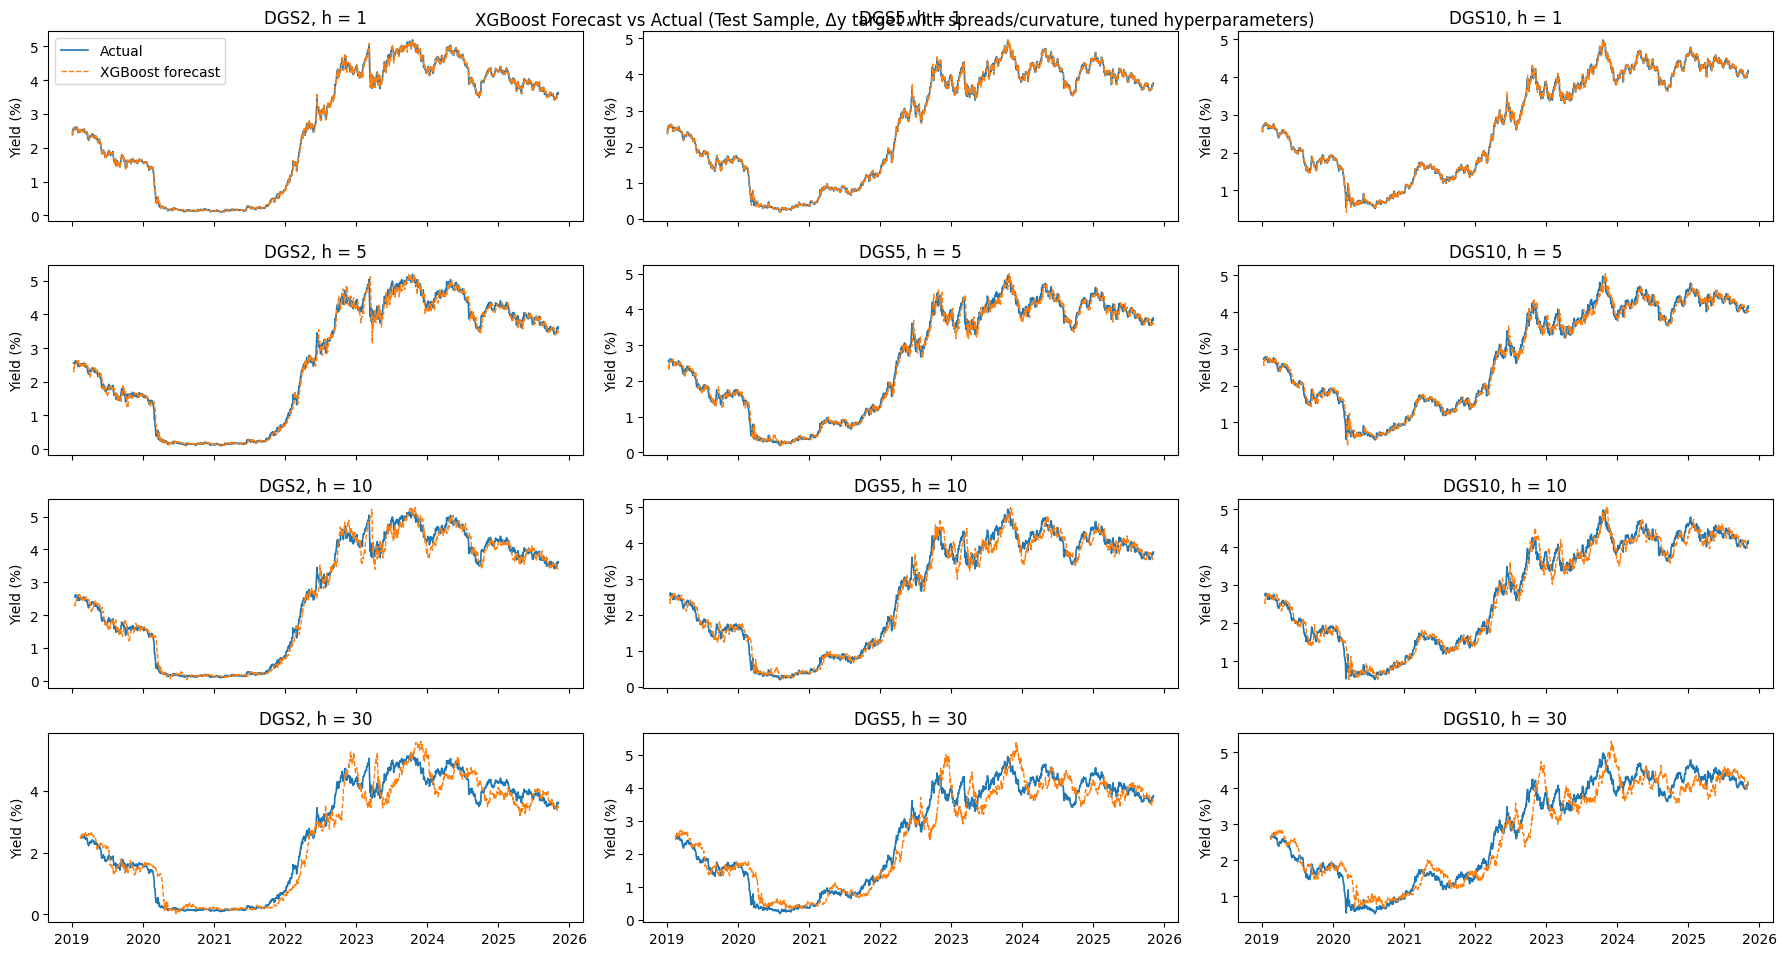

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# =====================================================
# 0. Settings
# =====================================================
maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-05")

min_train_size = 252  # at least ~1 year of data

merged = merged.sort_index()
idx = merged.index

# =====================================================
# 1. GPU / CPU toggle
# =====================================================
USE_GPU = False  # set False on MacBook, True on RTX desktop with gpu_hist support

if USE_GPU:
    tree_method = "gpu_hist"   # GPU-accelerated hist algorithm
else:
    tree_method = "hist"       # CPU version

# =====================================================
# 2. Helper: build lagged dataset (Δy target + spreads/curvature)
# =====================================================
def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
    """
    For each date t (origin):
      Features (information set at time t):
        - Yields of all maturities with lags 0..max_lag
        - Spreads and curvature with lags 0..max_lag
          * spread_5_2  = DGS5  - DGS2
          * spread_10_2 = DGS10 - DGS2
          * curv_5      = 2*DGS5 - DGS2 - DGS10

      Target:
        - Yield change Δy_{t+h} = y_{t+h} - y_t for target_col

      Index:
        - origin dates t
    """
    # Base yields
    base = merged[maturity_cols].copy()

    # Spreads & curvature
    base["spread_5_2"]  = base["DGS5"]  - base["DGS2"]
    base["spread_10_2"] = base["DGS10"] - base["DGS2"]
    base["curv_5"]      = 2 * base["DGS5"] - base["DGS2"] - base["DGS10"]

    cols_for_lags = maturity_cols + ["spread_5_2", "spread_10_2", "curv_5"]

    df = pd.DataFrame(index=merged.index)

    # Lagged features
    for col in cols_for_lags:
        for lag in range(0, max_lag + 1):
            df[f"{col}_lag{lag}"] = base[col].shift(lag)

    # Target: Δy_{t+h} = y_{t+h} - y_t
    df["target_delta"] = merged[target_col].shift(-horizon) - merged[target_col]

    df = df.dropna()

    feature_cols = [c for c in df.columns if c != "target_delta"]
    X = df[feature_cols].values
    y = df["target_delta"].values
    dates = df.index  # origin dates t

    return X, y, dates

# =====================================================
# 3. Helper: expanding-window XGBoost (strict, no look-ahead, Δy -> LEVEL)
# =====================================================
def expanding_window_xgb(
    X, y, dates, horizon,
    train_start, test_start, test_end,
    base_params, target_series,
    min_train_size=252
):
    """
    Expanding-window forecasting with NO look-ahead, using Δy targets.

    - Supervised rows (X, y) are indexed by origin date t (in 'dates').
    - Each row uses features at t and target Δy_{t+h} = y_{t+h} - y_t.
    - At a forecast origin t0 (calendar date), we may only train on rows
        with t <= t0 - h,
      so that all targets y_{t+h} in the training set are in the past
      relative to t0.
    - Model predicts Δy_hat; we reconstruct LEVEL forecast as:
        y_hat_{t0+h|t0} = y_t0 + Δy_hat
      and only keep forecasts where forecast_date in [test_start, test_end].
    """

    dates = pd.DatetimeIndex(dates)

    # Map dataset dates -> row index in X, y
    ds_idx_map = {d: i for i, d in enumerate(dates)}

    idx = merged.index
    idx_array = np.array(idx)

    # Origin dates t0 in calendar time
    origin_mask = (idx_array >= test_start) & (idx_array <= test_end)
    origin_positions = np.where(origin_mask)[0]
    if len(origin_positions) == 0:
        return None, None

    last_pos = len(idx) - 1
    pred_dict = {}
    debug_count = 0  # limit debug prints

    for pos in origin_positions:
        origin_date = idx[pos]  # t0

        # Need at least 'horizon' days of history to define t0 - h
        if pos - horizon < 0:
            continue

        # Calendar date t0 - h (h index steps back)
        train_end_date = idx[pos - horizon]

        # origin_date must exist in supervised dataset
        if origin_date not in ds_idx_map:
            continue

        # Forecast date t0 + h
        forecast_pos = pos + horizon
        if forecast_pos > last_pos:
            continue
        forecast_date = idx[forecast_pos]

        # Only keep forecasts inside [test_start, test_end]
        if forecast_date < test_start or forecast_date > test_end:
            continue

        # Training rows: t in [train_start, t0 - h]
        train_mask_ds = (dates >= train_start) & (dates <= train_end_date)
        train_idx_ds = np.where(train_mask_ds)[0]

        if len(train_idx_ds) < min_train_size:
            continue

        X_train, y_train = X[train_idx_ds], y[train_idx_ds]

        origin_row = ds_idx_map[origin_date]
        X_origin = X[origin_row:origin_row+1]

        # DEBUG: print a few origins to verify no look-ahead
        if debug_count < 5:
            debug_count += 1
            print(
                f"[DEBUG TEST XGB Δy] origin={origin_date.date()}, "
                f"train_end_date(t0-h)={train_end_date.date()}, "
                f"max_train_t={dates[train_idx_ds].max().date()}, "
                f"forecast_date(t0+h)={forecast_date.date()}"
            )
            # hard assertion: latest training t must be <= t0 - h
            assert dates[train_idx_ds].max() <= train_end_date, \
                "DATA LEAK: training uses dates after t0 - h!"

        # New XGB model each origin, with fixed tuned params, trained on Δy
        model = XGBRegressor(
            objective="reg:squarederror",
            learning_rate=base_params["eta"],
            max_depth=base_params["max_depth"],
            n_estimators=base_params["n_estimators"],
            subsample=0.7,
            colsample_bytree=0.7,
            min_child_weight=1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            tree_method=tree_method,
        )

        model.fit(X_train, y_train)
        delta_hat = model.predict(X_origin)[0]

        # Reconstruct LEVEL forecast: y_hat_{t0+h|t0} = y_t0 + Δy_hat
        y_level_t0 = target_series.loc[origin_date]
        y_hat_level = y_level_t0 + delta_hat

        pred_dict[forecast_date] = y_hat_level

    if len(pred_dict) == 0:
        return None, None

    pred_s = pd.Series(pred_dict).sort_index()
    actual_s = target_series.loc[pred_s.index]

    return pred_s, actual_s

# =====================================================
# 4. Final XGBoost evaluation (using tuned hyperparameters)
#    xgb_best_params must be defined beforehand
# =====================================================

xgb_pred_series = {}
xgb_actual_series = {}
results = []

for target_col in maturity_cols:
    target_series_full = merged[target_col]  # LEVEL series

    for h in horizons:
        best = xgb_best_params.get((target_col, h), None)
        if best is None:
            print(f"No best params found for {target_col}, h={h}, skipping.")
            continue

        p            = best["p"]
        eta          = best["eta"]
        max_depth    = best["max_depth"]
        n_estimators = best["n_estimators"]

        print(f"\nRunning XGBoost forecasts for {target_col}, h={h} "
              f"(Δy target; p={p}, eta={eta}, depth={max_depth}, trees={n_estimators}) ...")

        # Build supervised dataset with this lag length (Δy target + spreads/curvature)
        X, y, dates = build_lagged_dataset(
            merged=merged,
            maturity_cols=maturity_cols,
            target_col=target_col,
            horizon=h,
            max_lag=p
        )

        base_params = {
            "p": p,
            "eta": eta,
            "max_depth": max_depth,
            "n_estimators": n_estimators
        }

        # Run expanding-window XGBoost forecasting (strict, Δy -> LEVEL)
        pred_s, actual_s = expanding_window_xgb(
            X=X,
            y=y,
            dates=dates,
            horizon=h,
            train_start=train_start,
            test_start=test_start,
            test_end=test_end,
            base_params=base_params,
            target_series=target_series_full,
            min_train_size=min_train_size
        )

        if pred_s is None:
            print(f"  -> No forecasts produced for {target_col}, h={h}")
            continue

        errors = actual_s - pred_s

        rmse = np.sqrt(np.mean(errors**2))
        mean_err = errors.mean()
        std_err = errors.std(ddof=1)

        results.append({
            "Maturity": target_col,
            "Horizon": h,
            "RMSE": rmse,
            "Mean_Error": mean_err,
            "Std_Error": std_err,
            "N_Forecasts": len(errors),
            "p": p,
            "eta": eta,
            "max_depth": max_depth,
            "n_estimators": n_estimators
        })

        xgb_pred_series[(target_col, h)] = pred_s
        xgb_actual_series[(target_col, h)] = actual_s

# =====================================================
# 5. Results table
# =====================================================
xgb_results_df = pd.DataFrame(results)
xgb_results_df = xgb_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("\nXGBoost (expanding window, Δy target with spreads/curvature, tuned hyperparameters) performance (test period):")
display(xgb_results_df)

# =====================================================
# 6. Visualization: actual vs XGBoost forecast (same style as Ridge/DNS/RW)
# =====================================================
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 10),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]
        key = (col, h)

        if key not in xgb_pred_series:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = xgb_actual_series[key]
        pred_series   = xgb_pred_series[key]

        # Optional: zoom into last N observations
        N = len(actual_series)  # or e.g. 500
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="XGBoost forecast",
                linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("XGBoost Forecast vs Actual (Test Sample, Δy target with spreads/curvature, tuned hyperparameters)", y=0.95)
plt.tight_layout()
plt.show()


# Saving model results

In [ ]:
import pickle

# Save predictions and metadata
with open("../models/XGBoost.pkl", "wb") as f:
    pickle.dump({
        "pred_series": xgb_pred_series,
        "actual_series": xgb_actual_series,
        "results_df": xgb_results_df,
        "params": xgb_best_params
    }, f)


# Reloading Model Result

In [14]:
import pickle

with open("../models/XGB.pkl", "rb") as f:
    saved = pickle.load(f)

xgb_pred_series = saved["pred_series"]
xgb_actual_series = saved["actual_series"]
xgb_results_df = saved["results_df"]
xgb_best_params = saved["params"]


# Performance Evaluation

## Diebold-Marino Test

In [11]:
import numpy as np
from scipy.stats import norm

def dm_test(errors_model1, errors_model2, h=1, lag=None):
    """
    Diebold-Mariano test for equal predictive accuracy (squared-error loss).

    Parameters
    ----------
    errors_model1 : array-like
        Forecast errors of model 1 (y - y_hat1), length N.
    errors_model2 : array-like
        Forecast errors of model 2 (y - y_hat2), length N.
    h : int, optional
        Forecast horizon (in periods). Used only if lag is None.
    lag : int, optional
        Newey-West truncation lag for HAC variance.
        If None, lag is set to max(h-1, 0).

    Returns
    -------
    dm_stat : float
        Diebold-Mariano test statistic.
    p_value : float
        Two-sided p-value under asymptotic N(0,1).
    """

    e1 = np.asarray(errors_model1)
    e2 = np.asarray(errors_model2)

    # Drop NaNs in parallel
    mask = np.isfinite(e1) & np.isfinite(e2)
    e1 = e1[mask]
    e2 = e2[mask]

    if e1.shape != e2.shape:
        raise ValueError("Error series must have the same length after NaN removal.")

    N = len(e1)
    if N < 5:
        raise ValueError("Not enough observations for DM test.")

    # Squared-error loss
    L1 = e1 ** 2
    L2 = e2 ** 2

    # Loss differential
    d = L1 - L2
    d_bar = np.mean(d)

    # Newey–West HAC variance of d_t
    if lag is None:
        lag = max(h - 1, 0)

    d_centered = d - d_bar
    gamma0 = np.dot(d_centered, d_centered) / N
    var_d = gamma0

    for k in range(1, lag + 1):
        cov = np.dot(d_centered[k:], d_centered[:-k]) / N
        weight = 1.0 - k / (lag + 1)  # Bartlett weight
        var_d += 2.0 * weight * cov

    dm_stat = d_bar / np.sqrt(var_d / N)
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value


In [15]:
# -----------------------------
# 1) Collect prediction dicts
# -----------------------------
model_preds = {
    "RW":    rw_pred_series,      # dict[(maturity, h)] -> forecast series
    "DNS":   dns_pred_series,
    "Ridge": ridge_pred_series,
    "XGB":   xgb_pred_series,
}

# Corresponding actual series (they *should* all be identical per (mat, h),
# but we will just use RW's as canonical ground truth)
model_actuals = {
    "RW":    rw_actual_series,
    "DNS":   dns_actual_series,
    "Ridge": ridge_actual_series,
    "XGB":   xgb_actual_series,
}

maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

dm_results = []

for maturity in maturity_cols:
    for h in horizons:
        key = (maturity, h)

        # Use RW's actual series as canonical ground truth for this (maturity, h)
        if key not in rw_actual_series:
            continue

        actual = rw_actual_series[key].copy()
        actual.name = "actual"

        # Build a dict of aligned prediction series for all models that exist
        preds_for_key = {}
        for model_name, pred_dict in model_preds.items():
            if key not in pred_dict:
                continue
            preds_for_key[model_name] = pred_dict[key].rename(model_name)

        # Need at least RW + one other model with forecasts
        if "RW" not in preds_for_key or len(preds_for_key) < 2:
            continue

        # Compare each non-RW model against RW
        for model_name, pred_series in preds_for_key.items():
            if model_name == "RW":
                continue

            # Pairwise alignment: actual, RW, and the other model
            df_pair = pd.concat(
                [actual,
                 preds_for_key["RW"],
                 pred_series],
                axis=1,
                join="inner"
            ).dropna()

            if df_pair.empty:
                continue

            # Forecast errors: e = actual - prediction
            err_rw    = df_pair["actual"] - df_pair["RW"]
            err_other = df_pair["actual"] - df_pair[model_name]

            # Diebold–Mariano test (RW as Model 1, other model as Model 2)
            dm_stat, p_val = dm_test(err_rw.values, err_other.values, h=h)

            dm_results.append({
                "Maturity": maturity,
                "Horizon":  h,
                "Model_1":  "RW",
                "Model_2":  model_name,
                "DM_stat":  dm_stat,
                "p_value":  p_val,
                "N":        len(df_pair)
            })

dm_results_df = pd.DataFrame(dm_results)
dm_results_df = dm_results_df.sort_values(["Maturity", "Horizon", "Model_2"])

print(dm_results_df)


   Maturity  Horizon Model_1 Model_2    DM_stat       p_value     N
24    DGS10        1      RW     DNS -12.676666  0.000000e+00  1724
25    DGS10        1      RW   Ridge -12.725737  0.000000e+00  1724
26    DGS10        1      RW     XGB -13.081711  0.000000e+00  1712
27    DGS10        5      RW     DNS  -8.635730  0.000000e+00  1716
28    DGS10        5      RW   Ridge  -8.619960  0.000000e+00  1716
29    DGS10        5      RW     XGB  -8.842232  0.000000e+00  1708
30    DGS10       10      RW     DNS  -6.674684  2.477663e-11  1706
31    DGS10       10      RW   Ridge  -6.684741  2.313327e-11  1706
32    DGS10       10      RW     XGB  -7.100229  1.245448e-12  1703
33    DGS10       30      RW     DNS  -4.283127  1.842846e-05  1666
34    DGS10       30      RW   Ridge  -4.528040  5.953334e-06  1666
35    DGS10       30      RW     XGB  -4.569642  4.885570e-06  1666
0      DGS2        1      RW     DNS  -8.599884  0.000000e+00  1724
1      DGS2        1      RW   Ridge  -8.516107 

In [16]:
dm_results_df

,Maturity,Horizon,Model_1,Model_2,DM_stat,p_value,N
24,DGS10,1,RW,DNS,-12.676666,0.000000e+00,1724
25,DGS10,1,RW,Ridge,-12.725737,0.000000e+00,1724
26,DGS10,1,RW,XGB,-13.081711,0.000000e+00,1712
27,DGS10,5,RW,DNS,-8.635730,0.000000e+00,1716
28,DGS10,5,RW,Ridge,-8.619960,0.000000e+00,1716
29,DGS10,5,RW,XGB,-8.842232,0.000000e+00,1708
30,DGS10,10,RW,DNS,-6.674684,2.477663e-11,1706
31,DGS10,10,RW,Ridge,-6.684741,2.313327e-11,1706
32,DGS10,10,RW,XGB,-7.100229,1.245448e-12,1703
33,DGS10,30,RW,DNS,-4.283127,1.842846e-05,1666


# Economic Value Evaluation

## Long-Short Trading Strategy

To evaluate whether the forecasts provide return-generating value, we implement a simple long–short strategy based on the predicted excess return of each maturity. The strategy is applied separately for each maturity (2y, 5y, 10y) and each forecast horizon 
ℎ
∈
{
1
,
5
,
10
,
30
}
h∈{1,5,10,30}.

At each forecast date, the model issues a directional signal based on the predicted excess return:

If predicted excess return > 0  → take a long position
If predicted excess return < 0  → take a short position


The corresponding realized profit for the trade is computed as:

Profit = (predicted excess return) × (realized excess return) × 100


The constant factor represents a fixed notional investment and scales returns without affecting rankings.

This approach allows us to measure whether forecasts correctly anticipate the direction and magnitude of price movements. If forecasts are useful, long positions should coincide with positive realized excess returns and short positions with negative ones.

Performance is summarized using:

average trading profit

standard deviation of profits

Sharpe ratio

cumulative profit

A forecasting method is considered economically valuable if it generates higher profits and higher Sharpe ratios compared to the random walk benchmark and other competing models.

Define Helper Functions

In [18]:
maturity_durations = {
    "DGS2": 2.0,
    "DGS5": 5.0,
    "DGS10": 10.0,
}

def compute_predicted_excess_return(pred_yield_series, merged_yields, short_rate,
                                    maturity_col, horizon):
    """
    Forecasted excess holding-period return er̂_{t+h} for maturity_col
    over 'horizon' days, indexed by t+h.
    
    er̂_{t+h} = r̂_{t+h} - y_short_{t+h}
              ≈ -D * (ŷ_{t+h} - y_t) - y_short_{t+h}
    """
    D = maturity_durations[maturity_col]
    idx = pred_yield_series.index          # t+h

    # yield at start of period: y_t = y_{(t+h) - h}
    y_start = merged_yields[maturity_col].shift(horizon).loc[idx]
    # predicted yield at end of period: ŷ_{t+h}
    y_end_pred = pred_yield_series

    dy_pred = y_end_pred - y_start
    r_hat = -D * dy_pred

    # short-term rate y^{(1)}_{t+h}
    short_at_end = short_rate.loc[idx]

    er_pred = r_hat - short_at_end
    return er_pred.dropna()



def compute_realized_excess_return(merged_yields, short_rate, maturity_col,
                                   horizon, idx):
    """
    Realized excess holding-period return er_{t+h} for maturity_col,
    over 'horizon' days, indexed by t+h.
    """
    D = maturity_durations[maturity_col]
    y = merged_yields[maturity_col]

    y_end = y.loc[idx]                     # y_{t+h}
    y_start = y.shift(horizon).loc[idx]    # y_t

    dy_real = y_end - y_start
    r_real = -D * dy_real

    short_at_end = short_rate.loc[idx]     # y^{(1)}_{t+h}
    er_real = r_real - short_at_end

    return er_real.dropna()


import numpy as np

def compute_trading_profits(er_pred, er_real, notional=100.0):
    """
    π_{t+h} = er̂_{t+h} * er_{t+h} * notional
    """
    # saubere Schnittmenge der Indizes
    common_idx = er_pred.index.intersection(er_real.index)
    er_pred_aligned = er_pred.loc[common_idx]
    er_real_aligned = er_real.loc[common_idx]

    pi = er_pred_aligned * er_real_aligned * notional
    return pi

def sharpe_ratio(pi_series):
    """
    Sharpe = mean(π) / std(π), mit Populations-Std (wie in deiner Formel).
    """
    mu = pi_series.mean()
    sigma = pi_series.std(ddof=0)  # 1/N statt 1/(N-1)
    return mu / sigma if sigma != 0 else np.nan



Set Prediction and Actual series

In [11]:
short_rate = DGS1["DGS1"]   # your separate DataFrame with the 1y/short rate

model_pred_series = {
    "RW":    rw_pred_series,
    "DNS":   dns_pred_series,
    "Ridge": ridge_pred_series,
    "XGB":   xgb_pred_series,
}

actual_series_dict = xgb_actual_series   # any of your actual_* dicts is fine


Define Metrics and Loop over all Models, Horizons and Maturities

In [20]:
trading_results = []

for maturity in maturity_cols:
    for h in horizons:
        key = (maturity, h)

        if key not in actual_series_dict:
            continue

        # realized excess returns (same for all models)
        er_realized = compute_realized_excess_return(
            merged_yields=merged,
            short_rate=short_rate,
            maturity_col=maturity,
            idx = idx,
            horizon=h
        )

        for model_name, pred_dict in model_pred_series.items():
            if key not in pred_dict:
                continue

            pred_yields = pred_dict[key]

            er_pred = compute_predicted_excess_return(
                pred_yield_series=pred_yields,
                merged_yields=merged,
                short_rate=short_rate,
                maturity_col=maturity,
                horizon=h
            )

            df_tmp = (
                pd.DataFrame({"er_realized": er_realized})
                .join(er_pred.rename("er_pred"), how="inner")
                .dropna()
            )
            if df_tmp.empty:
                continue

            pnl = df_tmp["er_pred"] * df_tmp["er_realized"] * 100.0

            avg_profit = pnl.mean()
            sr = sharpe_ratio(pnl)
            N = len(pnl)

            trading_results.append({
                "Maturity": maturity,
                "Horizon": h,
                "Model": model_name,
                "Avg_Profit": avg_profit,
                "Sharpe": sr,
                "N_Trades": N,
            })

trading_results_df = pd.DataFrame(trading_results).sort_values(
    ["Horizon", "Maturity", "Model"]
)

print(trading_results_df)


   Maturity  Horizon  Model   Avg_Profit    Sharpe  N_Trades
33    DGS10        1    DNS  1112.876675  1.047805      1725
32    DGS10        1     RW  1150.231206  1.007698      1725
34    DGS10        1  Ridge  1112.971434  1.047631      1725
35    DGS10        1    XGB  1105.697360  1.044828      1712
1      DGS2        1    DNS  1110.841017  1.071999      1725
0      DGS2        1     RW  1111.998557  1.068423      1725
2      DGS2        1  Ridge  1110.959436  1.072011      1725
3      DGS2        1    XGB  1106.538734  1.067783      1712
17     DGS5        1    DNS  1111.013883  1.064827      1725
16     DGS5        1     RW  1121.323670  1.048274      1725
18     DGS5        1  Ridge  1110.916779  1.064787      1725
19     DGS5        1    XGB  1105.411023  1.061400      1712
37    DGS10        5    DNS  1125.411213  0.969990      1721
36    DGS10        5     RW  1300.188199  0.877546      1721
38    DGS10        5  Ridge  1128.944991  0.968644      1721
39    DGS10        5    

### Sanity check the result by deriving it from scratch

In [21]:
maturity = "DGS5"
h = 5
model = "Ridge"   # or "XGBoost" / "RW" / "DNS"

pred_series = ridge_pred_series[(maturity, h)]
actual_series = ridge_actual_series[(maturity, h)]   # actual realized yields (observed)


In [26]:
idx = pred_series.index

# Duration
D = maturity_durations[maturity]

# Start-of-holding yield y_t
y_start = merged[maturity].shift(h).loc[idx]

# Predicted end-of-holding yield ŷ_{t+h}
y_pred_end = pred_series

dy_pred = y_pred_end - y_start
r_hat = -D * dy_pred

r_hat.head()


2019-01-09   -0.071081
2019-01-10   -0.071729
2019-01-11   -0.013404
2019-01-14   -0.041894
2019-01-15   -0.050169
dtype: float64

Calculate the predicted Excess return

In [27]:
short = short_rate.loc[idx]

er_pred_manual = r_hat - short
er_pred_manual.head()


2019-01-09   -2.661081
2019-01-10   -2.661729
2019-01-11   -2.593404
2019-01-14   -2.611894
2019-01-15   -2.620169
dtype: float64

In [28]:
er_pred_func = compute_predicted_excess_return(pred_series, merged, short_rate, maturity, h)

er_pred_manual.head(), er_pred_func.head()

(2019-01-09   -2.661081
 2019-01-10   -2.661729
 2019-01-11   -2.593404
 2019-01-14   -2.611894
 2019-01-15   -2.620169
 dtype: float64,
 2019-01-09   -2.661081
 2019-01-10   -2.661729
 2019-01-11   -2.593404
 2019-01-14   -2.611894
 2019-01-15   -2.620169
 dtype: float64)

Calculate the realized excess return

In [29]:
y_real_end = merged[maturity].loc[idx]
y_real_start = merged[maturity].shift(h).loc[idx]

dy_real = y_real_end - y_real_start
r_real = -D * dy_real

er_real_manual = r_real - short
er_real_manual.head()


2019-01-09   -2.99
2019-01-10   -3.54
2019-01-11   -2.73
2019-01-14   -2.57
2019-01-15   -2.32
dtype: float64

In [30]:
er_real_func = compute_realized_excess_return(merged, short_rate, maturity, h, idx)

er_real_manual.head(), er_real_func.head()


(2019-01-09   -2.99
 2019-01-10   -3.54
 2019-01-11   -2.73
 2019-01-14   -2.57
 2019-01-15   -2.32
 dtype: float64,
 2019-01-09   -2.99
 2019-01-10   -3.54
 2019-01-11   -2.73
 2019-01-14   -2.57
 2019-01-15   -2.32
 dtype: float64)

Calculate Trading Profit

In [31]:
pi_manual = er_pred_manual * er_real_manual * 100
pi_manual.head()


2019-01-09    795.663294
2019-01-10    942.251930
2019-01-11    707.999239
2019-01-14    671.256769
2019-01-15    607.879136
dtype: float64

In [32]:
pi_func = compute_trading_profits(er_pred_func, er_real_func, notional=100)

pi_manual.head(), pi_func.head()


(2019-01-09    795.663294
 2019-01-10    942.251930
 2019-01-11    707.999239
 2019-01-14    671.256769
 2019-01-15    607.879136
 dtype: float64,
 2019-01-09    795.663294
 2019-01-10    942.251930
 2019-01-11    707.999239
 2019-01-14    671.256769
 2019-01-15    607.879136
 dtype: float64)

Compute Metrics

In [37]:
mu_manual = pi_manual.mean()
mu_manual

sigma_manual = pi_manual.std(ddof=0)
sigma_manual

sharpe_manual = mu_manual / sigma_manual
sharpe_manual

mu_manual, sigma_manual, sharpe_manual, sharpe_ratio(pi_manual)


(np.float64(1116.9277244114794),
 np.float64(1078.981271430281),
 np.float64(1.0351687781669252),
 np.float64(1.0351687781669252))

# Portfolio Optimization Problem

In [52]:
import numpy as np
import pandas as pd
from numpy.linalg import inv, solve
from cvxopt import matrix, solvers  # für No-Short-Selling-Version (QP)

# ---------------------------------------------------
# Settings
# ---------------------------------------------------
maturity_cols = ["DGS2", "DGS5", "DGS10"]
tau_years = np.array([2.0, 5.0, 10.0])  # Maturities in Jahren

horizons = [1, 5, 10, 30]

train_start = pd.Timestamp("2009-01-02")
test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-25")

TRADING_DAYS_PER_YEAR = 252
ROLLING_WINDOW = 252   # Anzahl vergangener h-Perioden-Returns für Sigma_r
delta = 1.0            # Risikoaversion
no_short = True       # True -> w_t >= 0

# Risk-free Rate: DGS1 (annualisiert, in Dezimalform)
# rf_series: pd.Series mit Index = Datum, Wert = 1y yield (decimal)
rf_series = viz_merged["DGS1"] / 100.0   # falls viz_merged schon existiert


# ---------------------------------------------------
# 1. h-periodige Bond-Returns r_{t,t+h}(τ) (ohne rf)
#     r ≈ -τ (y_{t+h} - y_t)
# ---------------------------------------------------
def compute_horizon_returns(merged, maturity_cols, tau_years, h):
    """
    Berechnet h-Perioden-Bond-Returns r_{t,t+h}(τ) für jede Maturity.
    Index = Origin-Datum t, Spalten = Maturities.
    """
    yields = merged[maturity_cols] / 100.0  # in Dezimal
    idx = list(yields.index)

    rows = []
    dates = []

    for i in range(len(idx) - h):
        t   = idx[i]       # Start
        t_h = idx[i + h]   # Ende

        y_t  = yields.loc[t].values
        y_th = yields.loc[t_h].values

        # log-return-Approximation für Zero-Coupon:
        # r_{t,t+h} ≈ -τ (y_{t+h} - y_t)
        r = -tau_years * (y_th - y_t)    # shape (3,)

        rows.append(r)
        dates.append(t)

    r_df = pd.DataFrame(rows, index=pd.DatetimeIndex(dates), columns=maturity_cols)
    return r_df


# Precompute Returns für alle Horizonte (ohne rf)
returns_by_h = {
    h: compute_horizon_returns(merged, maturity_cols, tau_years, h)
    for h in horizons
}


# ---------------------------------------------------
# 2. Erwartete Bond-Returns μ^{(m)}_{r|t+h} aus Yield-Forecasts
#    Annahme: pred_dict[(col, h)] hat Index = Zieldatum t+h
# ---------------------------------------------------
def expected_returns_from_forecasts(merged, pred_dict, maturity_cols, tau_years, h):
    """
    Erwartete Bond-Returns μ_{r|t+h}^{(m)} aus Yield-Forecasts.

    Annahme: pred_dict[(maturity_col, h)] hat Index = Origin-Datum t
             und enthält ŷ_{t+h|t}(τ) in Prozent.

    Rückgabe:
        mu_df: DataFrame (Index = t, Spalten = maturities)
               mit erwarteten Bond-Returns μ_{r|t+h} (ohne rf).
    """
    yields = merged[maturity_cols] / 100.0  # in Dezimal

    # gemeinsame Origin-Daten, für die es Forecasts für alle Maturities gibt
    date_lists = [pred_dict[(col, h)].index for col in maturity_cols]
    common_dates = sorted(set(date_lists[0]).intersection(*date_lists[1:]))

    mu_rows = []
    mu_dates = []

    for t in common_dates:
        if t not in yields.index:
            continue

        # tatsächliche Yields am Startdatum t
        y_t = yields.loc[t].values  # shape (3,)

        # Forecasts ŷ_{t+h|t}(τ) (in Dezimal)
        y_hat_vals = np.array(
            [pred_dict[(col, h)].loc[t] for col in maturity_cols]
        ) / 100.0

        # erwarteter Bond-Return:
        # μ_{r|t+h}(τ) ≈ -τ (ŷ_{t+h|t} - y_t)
        mu = -tau_years * (y_hat_vals - y_t)

        mu_rows.append(mu)
        mu_dates.append(t)

    mu_df = pd.DataFrame(mu_rows, index=pd.DatetimeIndex(mu_dates), columns=maturity_cols)
    return mu_df



# ---------------------------------------------------
# 3. Mean-Variance-Optimierung
#     min_w  w' Σ w - (1/δ) w' μ   s.t. 1'w = 1, optional w ≥ 0
# ---------------------------------------------------
def solve_mv(mu_vec, Sigma, delta=1.0, no_short=False):
    """
    Löse:  min_w  w' Σ w - (1/δ) w' μ
           s.t.   1'w = 1   (und optional w >= 0).
    Rückgabe: w (numpy array).
    """
    N = len(mu_vec)
    ones = np.ones(N)

    if not no_short:
        # Gleichungs-beschränktes Problem:
        # FOCs: 2Σw - (1/δ)μ + λ1 = 0,  1'w = 1
        # -> lineares System für (w, λ)
        K = np.block([
            [2 * Sigma,          ones.reshape(-1, 1)],
            [ones.reshape(1, -1), np.zeros((1, 1))]
        ])
        rhs = np.concatenate([(1.0 / delta) * mu_vec, np.array([1.0])])

        sol = solve(K, rhs)
        w = sol[:-1]   # letzter Eintrag ist λ
        return w

    else:
        # Quadratic Program mit w >= 0 via cvxopt
        # min (1/2) w' (2Σ) w + q'w,  q = -(1/δ) μ
        P = matrix(2 * Sigma)
        q = matrix(-(1.0 / delta) * mu_vec)

        # Ungleichungen: G w <= h   ->  -I w <= 0  (w >= 0)
        G = matrix(-np.eye(N))
        h_vec = matrix(np.zeros(N))

        # Gleichung: A w = b  -> 1'w = 1
        A = matrix(ones, (1, N))
        b = matrix(1.0)

        sol = solvers.qp(P, q, G, h_vec, A, b)
        w = np.array(sol['x']).flatten()
        return w


# ---------------------------------------------------
# 4. Strategie für ein Modell laufen lassen
# ---------------------------------------------------
def run_mv_strategy_for_model(model_name, pred_dict, returns_by_h,
                              merged, maturity_cols, tau_years,
                              horizons, rf_series,
                              delta=1.0, no_short=False,
                              rolling_window=252,
                              test_start=test_start,
                              test_end=test_end):

    results = {}

    for h in horizons:
        print(f"\n=== {model_name}: horizon h = {h} ===")

        # Realisierte Bond-Returns r_{t,t+h}(τ) (ohne rf)
        r_all = returns_by_h[h]

        # Erwartete Returns aus Forecasts (ohne rf), Index = t
        mu_df = expected_returns_from_forecasts(
            merged=merged,
            pred_dict=pred_dict,
            maturity_cols=maturity_cols,
            tau_years=tau_years,
            h=h
        )

        # Gemeinsame Datumsmenge innerhalb Testfenster
        dates = sorted(set(r_all.index).intersection(mu_df.index))
        dates = [d for d in dates if (d >= test_start) and (d <= test_end)]

        port_excess_returns = []

        rebalance_dates = dates[::h]
        for t in rebalance_dates:
            # Vergangenes Fenster für Σ_r: Returns vor t
            rx_past = r_all.loc[r_all.index < t].tail(rolling_window)

            if len(rx_past) < len(maturity_cols) + 1:
                # Zu wenig Daten für vernünftige Kovarianzschätzung
                continue

            Sigma_r = np.cov(rx_past.values.T, ddof=1)
            mu_vec  = mu_df.loc[t].values   # erwartete Returns (ohne rf)

            # MV-Gewichte
            w_t = solve_mv(mu_vec, Sigma_r, delta=delta, no_short=no_short)

            # Realisierter Bond-Return des Portfolios von t bis t+h
            r_t = r_all.loc[t].values
            r_port_t = np.dot(w_t, r_t)

            # h-period risk-free (einfache Approximation rf_t * h/252)
            if t in rf_series.index:
                rf_h = rf_series.loc[t] * (h / TRADING_DAYS_PER_YEAR)
            else:
                rf_h = 0.0

            # Portfolio-Excess-Return
            rx_port_t = r_port_t - rf_h
            port_excess_returns.append((t, rx_port_t))

        if len(port_excess_returns) == 0:
            print("  -> no valid portfolio returns for this horizon.")
            continue

        port_df = pd.DataFrame(port_excess_returns, columns=["date", "rx_port"])
        port_df.set_index("date", inplace=True)
        results[h] = port_df

        # Sharpe Ratio der Excess Returns
        mean_rx = port_df["rx_port"].mean()
        std_rx  = port_df["rx_port"].std(ddof=1)
        sharpe  = mean_rx / std_rx if std_rx > 0 else np.nan

        print(f"  N = {len(port_df)}  |  mean rx = {mean_rx:.5f},  std = {std_rx:.5f},  SR = {sharpe:.3f}")

    return results


In [48]:
models = {
    "RW": rw_predictions,
    "DNS": dns_pred_series,
    "Ridge": ridge_pred_series,
    "XGBoost": xgb_pred_series,
}


In [53]:
mv_results = {}   # Speichert vollständige Zeitreihen je Modell & Horizon
summary_rows = [] # Für Sharpe-Tabelle

for model_name, pred_dict in models.items():
    print(f"\n==================== MODEL: {model_name} ====================")

    result = run_mv_strategy_for_model(
        model_name=model_name,
        pred_dict=pred_dict,
        returns_by_h=returns_by_h,
        merged=merged,
        maturity_cols=maturity_cols,
        tau_years=tau_years,
        horizons=horizons,
        rf_series=rf_series,
        delta=delta,
        no_short=no_short,
        rolling_window=ROLLING_WINDOW,
        test_start=test_start,
        test_end=test_end
    )

    mv_results[model_name] = result

    # Werte extrahieren für Vergleichstabelle
    for h in result:
        port_df = result[h]
        mean_rx = port_df["rx_port"].mean()
        std_rx  = port_df["rx_port"].std(ddof=1)
        sharpe  = mean_rx / std_rx if std_rx > 0 else np.nan

        summary_rows.append({
            "Model": model_name,
            "Horizon": h,
            "N": len(port_df),
            "Mean Excess Return": mean_rx,
            "StdDev": std_rx,
            "Sharpe": sharpe
        })

summary_df = pd.DataFrame(summary_rows).sort_values(["Horizon", "Model"])
summary_df



==================== MODEL: RW ====================

=== RW: horizon h = 1 ===
     pcost       dcost       gap    pres   dres
 0:  3.5086e-06 -1.0000e+00  1e+00  1e-16  2e+00
 1:  3.5086e-06 -1.0002e-02  1e-02  2e-16  2e-02
 2:  3.5045e-06 -1.0167e-04  1e-04  1e-16  2e-04
 3:  3.1634e-06 -2.4071e-06  6e-06  1e-16  1e-05
 4:  8.7033e-07 -5.8439e-07  1e-06  7e-16  2e-21
 5:  4.6042e-07  3.2658e-07  1e-07  1e-16  9e-22
 6:  3.5542e-07  3.4842e-07  7e-09  1e-16  1e-21
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  3.6565e-06 -1.0000e+00  1e+00  6e-17  2e+00
 1:  3.6564e-06 -1.0002e-02  1e-02  1e-16  2e-02
 2:  3.6521e-06 -1.0171e-04  1e-04  1e-16  2e-04
 3:  3.2891e-06 -2.4319e-06  6e-06  2e-16  1e-05
 4:  9.0647e-07 -5.9803e-07  2e-06  1e-16  2e-21
 5:  4.8272e-07  3.4616e-07  1e-07  8e-17  2e-22
 6:  3.7472e-07  3.6798e-07  7e-09  2e-16  6e-22
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  3.8055e-06 -1.0000e+00  1e+00  6e-17 

,Model,Horizon,N,Mean Excess Return,StdDev,Sharpe
4,DNS,1,1724,-0.000169,0.004045,-0.041885
0,RW,1,1725,-0.000118,0.001231,-0.096017
8,Ridge,1,1724,-0.000180,0.004042,-0.044436
12,XGBoost,1,1712,-0.000186,0.004091,-0.045509
5,DNS,5,344,-0.000902,0.009075,-0.099358
1,RW,5,345,-0.000589,0.002691,-0.218984
9,Ridge,5,344,-0.000893,0.008972,-0.099492
13,XGBoost,5,342,-0.000951,0.009052,-0.105015
6,DNS,10,171,-0.001378,0.013307,-0.103521
2,RW,10,172,-0.001192,0.003755,-0.317386


### Santiy check by computing result from scratch

In [54]:
import numpy as np
import pandas as pd
from cvxopt import matrix, solvers

# ---------- SETTINGS ----------
h = 5
delta = 1.0
no_short = True  # wie in deinem letzten Run
maturity_cols = ["DGS2", "DGS5", "DGS10"]
tau_years = np.array([2.0, 5.0, 10.0])
ROLLING_WINDOW = 252
TRADING_DAYS_PER_YEAR = 252

# ---------- 1. Recompute h-period bond returns r_{t,t+h}(τ) ----------
yields = merged[maturity_cols] / 100.0
idx = list(yields.index)

rows = []
dates = []
for i in range(len(idx) - h):
    t   = idx[i]
    t_h = idx[i + h]
    y_t  = yields.loc[t].values
    y_th = yields.loc[t_h].values
    r_vec = -tau_years * (y_th - y_t)   # shape (3,)
    rows.append(r_vec)
    dates.append(t)

r_all = pd.DataFrame(rows, index=pd.DatetimeIndex(dates), columns=maturity_cols)

# ---------- 2. Expected returns μ_{r|t+h} from DNS forecasts ----------
def dns_expected_returns_from_forecasts(merged, pred_dict, maturity_cols, tau_years, h):
    yields = merged[maturity_cols] / 100.0

    # origin dates t where we have forecasts for all maturities
    date_lists = [pred_dict[(col, h)].index for col in maturity_cols]
    common_dates = sorted(set(date_lists[0]).intersection(*date_lists[1:]))

    mu_rows = []
    mu_dates = []

    for t in common_dates:
        if t not in yields.index:
            continue
        y_t = yields.loc[t].values
        y_hat_vals = np.array([pred_dict[(col, h)].loc[t] for col in maturity_cols]) / 100.0
        mu = -tau_years * (y_hat_vals - y_t)
        mu_rows.append(mu)
        mu_dates.append(t)

    mu_df = pd.DataFrame(mu_rows, index=pd.DatetimeIndex(mu_dates), columns=maturity_cols)
    return mu_df

mu_dns = dns_expected_returns_from_forecasts(merged, dns_pred_series, maturity_cols, tau_years, h)

# ---------- 3. Common dates, rebalance every h days ----------
dates = sorted(set(r_all.index).intersection(mu_dns.index))
# ggf. Testfenster einschränken – optional:
dates = [d for d in dates if (d >= pd.Timestamp("2019-01-02")) & (d <= pd.Timestamp("2025-11-25"))]
rebalance_dates = dates[::h]   # rebalance alle h Tage

# ---------- 4. Helper: MV with no-short ----------
def solve_mv_noshort(mu_vec, Sigma, delta=1.0):
    N = len(mu_vec)
    ones = np.ones(N)

    P = matrix(2 * Sigma)
    q = matrix(-(1.0 / delta) * mu_vec)

    G = matrix(-np.eye(N))
    h_vec = matrix(np.zeros(N))

    A = matrix(ones, (1, N))
    b = matrix(1.0)

    sol = solvers.qp(P, q, G, h_vec, A, b)
    w = np.array(sol['x']).flatten()
    return w

# ---------- 5. Manually compute portfolio excess return series ----------
port_rx = []

for t in rebalance_dates:
    # Kovarianzmatrix aus vergangenen Returns
    rx_past = r_all.loc[r_all.index < t].tail(ROLLING_WINDOW)
    if len(rx_past) < len(maturity_cols) + 1:
        continue

    Sigma_r = np.cov(rx_past.values.T, ddof=1)
    mu_vec  = mu_dns.loc[t].values

    w_t = solve_mv_noshort(mu_vec, Sigma_r, delta=delta)

    # realized bond return from t to t+h
    r_t = r_all.loc[t].values
    r_port_t = np.dot(w_t, r_t)

    # rf h-period return approximation
    rf_t = rf_series.loc[t]
    rf_h = rf_t * (h / TRADING_DAYS_PER_YEAR)

    rx_port_t = r_port_t - rf_h
    port_rx.append((t, rx_port_t))

port_rx_df = pd.DataFrame(port_rx, columns=["date", "rx_port"]).set_index("date")

# ---------- 6. Compute mean, std, Sharpe from scratch ----------
N = len(port_rx_df)
mean_rx = port_rx_df["rx_port"].mean()
std_rx  = port_rx_df["rx_port"].std(ddof=1)
sharpe  = mean_rx / std_rx if std_rx > 0 else np.nan

print("DNS h=5 – manual recomputation")
print(f"N = {N}")
print(f"Mean Excess Return = {mean_rx:.8f}")
print(f"StdDev = {std_rx:.8f}")
print(f"Sharpe = {sharpe:.6f}")


     pcost       dcost       gap    pres   dres
 0: -3.9733e-03 -1.0073e+00  1e+00  0e+00  2e+00
 1: -3.9862e-03 -1.7275e-02  1e-02  1e-16  3e-02
 2: -4.8573e-03 -7.3682e-03  3e-03  6e-17  6e-03
 3: -7.2119e-03 -7.5438e-03  3e-04  3e-16  8e-05
 4: -7.2599e-03 -7.2634e-03  3e-06  6e-19  9e-07
 5: -7.2605e-03 -7.2606e-03  3e-08  1e-16  9e-09
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  1.3372e-03 -9.9965e-01  1e+00  1e-16  2e+00
 1:  1.3363e-03 -9.6484e-03  1e-02  6e-17  3e-02
 2:  1.2486e-03  2.5317e-04  1e-03  8e-17  2e-03
 3:  3.7445e-04  1.0161e-04  3e-04  2e-15  2e-04
 4:  3.6243e-04  3.5942e-04  3e-06  1e-16  3e-06
 5:  3.6203e-04  3.6200e-04  3e-08  3e-17  3e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  5.4709e-04 -1.0001e+00  1e+00  1e-16  2e+00
 1:  5.4570e-04 -1.0055e-02  1e-02  2e-16  2e-02
 2:  4.3077e-04 -1.5254e-04  6e-04  2e-16  1e-03
 3: -3.7284e-05 -6.5768e-05  3e-05  9e-16  3e-05
 4: -4.2554e-05 -4.5434e

# Risk reduction strategy

To assess whether yield forecasts provide practical economic value, we implement a timing strategy aimed at reducing interest-rate risk. The investor holds an equal-weighted portfolio of zero-coupon U.S. Treasury bonds (2y, 5y, 10y) and we compare two approaches:

Buy-and-Hold (BH):
The investor remains fully invested throughout the entire out-of-sample period.

Forecast-Based Timing Strategy:
At each forecast horizon 
ℎ
∈
{
1
,
5
,
10
,
30
}
h∈{1,5,10,30}, the investment position depends on the sign of the forecasted excess return:

Position rule (plain text version):

If forecasted excess return > 0 → stay invested (position = 1)
If forecasted excess return ≤ 0 → move to cash (position = 0)


No leverage or short-selling is allowed.

Returns are measured as excess returns relative to the short-term rate, so holding cash corresponds to earning zero excess return.

Performance is evaluated using:

mean excess return

volatility

Sharpe ratio

maximum drawdown

A forecasting model is considered economically useful if it reduces drawdowns or improves risk-adjusted performance relative to Buy-and-Hold — especially in the rising-rate environment during 2019–2025.

In [8]:
import numpy as np
import pandas as pd

maturity_cols = ["DGS2", "DGS5", "DGS10"]
tau_years = np.array([2.0, 5.0, 10.0])  # in years

TRADING_DAYS_PER_YEAR = 252

def compute_horizon_bond_returns(merged, maturity_cols, tau_years, h):
    """
    Approximate h-period holding returns for each maturity using
    r_{t,t+h} ≈ -τ (y_{t+h} - y_t), with yields in decimal.
    
    Returns:
        DataFrame: index = t (start dates), columns = maturities
    """
    yields = merged[maturity_cols] / 100.0  # to decimal
    idx = list(yields.index)
    
    rows = []
    dates = []
    for i in range(len(idx) - h):
        t = idx[i]
        t_h = idx[i + h]
        
        y_t  = yields.loc[t].values    # shape (3,)
        y_th = yields.loc[t_h].values  # shape (3,)
        
        r_vec = -tau_years * (y_th - y_t)  # shape (3,)
        rows.append(r_vec)
        dates.append(t)
    
    r_df = pd.DataFrame(rows, index=pd.DatetimeIndex(dates), columns=maturity_cols)
    return r_df


def max_drawdown(return_series):
    """
    return_series: Series of (excess) returns.
    Computes max drawdown on cumulative wealth path (1 + returns).
    """
    cum = (1 + return_series).cumprod()
    peak = cum.cummax()
    dd = cum / peak - 1.0
    return dd.min()


In [25]:
def run_portfolio_timing_overlay(model_name,
                                 pred_dict,
                                 merged,
                                 short_rate,
                                 maturity_cols=maturity_cols,
                                 tau_years=tau_years,
                                 horizons=[1,5,10,30],
                                 weights=None,
                                 test_start=pd.Timestamp("2019-01-02"),
                                 test_end=pd.Timestamp("2025-11-25")):
    """
    Portfolio-timing overlay:
    - Base portfolio: long in all maturities with given weights.
    - Benchmark: always invested (buy & hold).
    - Overlay: invest only when forecasted portfolio excess return > 0,
      otherwise stay in cash (no bond exposure).
      
    Returns:
        summary_df: DataFrame of metrics per horizon
        detail_by_h: dict[h] -> DataFrame with columns
                     ["BH_excess", "Timing_excess"]
    """
    if weights is None:
        weights = np.ones(len(maturity_cols)) / len(maturity_cols)
    else:
        weights = np.array(weights)
        weights = weights / weights.sum()  # normalize just in case
    
    results = []
    detail_by_h = {}
    
    yields_dec = merged[maturity_cols] / 100.0  # decimal yields
    
    for h in horizons:
        print(f"\n=== {model_name} | horizon h={h} ===")
        
        # 1) Realized bond returns r_{t,t+h} for each maturity
        r_all = compute_horizon_bond_returns(merged, maturity_cols, tau_years, h)
        
        # restrict to test window
        r_all = r_all.loc[(r_all.index >= test_start) & (r_all.index <= test_end)]
        
        # 2) Find common dates where we have forecasts for all maturities
        date_lists = []
        for col in maturity_cols:
            key = (col, h)
            if key not in pred_dict:
                date_lists = []
                break
            date_lists.append(pred_dict[key].index)
        if not date_lists:
            print(f"  -> No forecasts for horizon {h}, skipping.")
            continue
        
        common_dates = sorted(set(date_lists[0]).intersection(*date_lists[1:]))
        common_dates = [d for d in common_dates if (d >= test_start) and (d <= test_end)]
        
        # intersection with dates where we have realized returns
        common_dates = sorted(set(common_dates).intersection(r_all.index))
        if not common_dates:
            print("  -> No common dates for forecasts and returns.")
            continue
        
        # Option: rebalance every h days (non-overlapping windows)
        rebalance_dates = common_dates[::h]
        
        bh_excess = []
        timing_excess = []
        
        for t in rebalance_dates:
            # realized bond return vector for t->t+h
            if t not in r_all.index:
                continue
            r_vec = r_all.loc[t].values  # shape (3,)
            
            # portfolio bond return
            r_port = np.dot(weights, r_vec)
            
            # risk-free h-period return from short_rate (DGS1)
            if t in short_rate.index:
                rf_t = short_rate.loc[t] / 100.0  # decimal
                rf_h = rf_t * (h / TRADING_DAYS_PER_YEAR)
            else:
                rf_h = 0.0
            
            # realized excess portfolio return
            er_port = r_port - rf_h
            
            # forecasts: y_t and y_hat_{t+h|t}
            if t not in yields_dec.index:
                continue
            y_t = yields_dec.loc[t].values  # actual yields at t
            
            y_hat_vals = np.array([
                pred_dict[(col, h)].loc[t] for col in maturity_cols
            ]) / 100.0  # to decimal
            
            # predicted bond returns per maturity
            r_hat_vec = -tau_years * (y_hat_vals - y_t)
            r_hat_port = np.dot(weights, r_hat_vec)
            er_hat_port = r_hat_port - rf_h  # expected excess portfolio return
            
            # benchmark: always invested
            bh_excess.append((t, er_port))
            
            # timing: invest only if expected excess return > 0
            position = 1.0 if er_hat_port > 0 else 0.0
            timing_excess.append((t, position * er_port))
        
        # build DataFrames
        if not bh_excess:
            print("  -> No valid observations, skipping.")
            continue
        
        bh_df = pd.DataFrame(bh_excess, columns=["date", "BH_excess"]).set_index("date")
        timing_df = pd.DataFrame(timing_excess, columns=["date", "Timing_excess"]).set_index("date")
        
        # align indexes
        idx_common = bh_df.index.intersection(timing_df.index)
        bh_df = bh_df.loc[idx_common]
        timing_df = timing_df.loc[idx_common]
        
        detail_by_h[h] = pd.concat([bh_df, timing_df], axis=1)
        
        # metrics
        bh_series = detail_by_h[h]["BH_excess"]
        tm_series = detail_by_h[h]["Timing_excess"]
        
        N = len(bh_series)
        
        bh_mean = bh_series.mean()
        bh_std  = bh_series.std(ddof=1)
        bh_sharpe = bh_mean / bh_std if bh_std > 0 else np.nan
        bh_mdd = max_drawdown(bh_series)

        bh_cumret = (1 + bh_series).prod() - 1
        bh_final_wealth = (1 + bh_series).cumprod().iloc[-1]
        
        tm_mean = tm_series.mean()
        tm_std  = tm_series.std(ddof=1)
        tm_sharpe = tm_mean / tm_std if tm_std > 0 else np.nan
        tm_mdd = max_drawdown(tm_series)

        tm_cumret = (1 + tm_series).prod() - 1
        tm_final_wealth = (1 + tm_series).cumprod().iloc[-1]
        
        risk_reduction_std = 1.0 - (tm_std / bh_std) if bh_std > 0 and tm_std >= 0 else np.nan
        
        print(f"  N={N}")
        print(f"  Buy&Hold    : mean={bh_mean:.6f}, std={bh_std:.6f}, Sharpe={bh_sharpe:.3f}, MDD={bh_mdd:.3%}")
        print(f"  Timing({model_name}): mean={tm_mean:.6f}, std={tm_std:.6f}, Sharpe={tm_sharpe:.3f}, MDD={tm_mdd:.3%}")
        print(f"  Std risk reduction: {risk_reduction_std:.3%}")
        
        results.append({
            "Model": model_name,
            "Horizon": h,
            "N": N,
            "BH_Mean": bh_mean,
            "BH_Std": bh_std,
            "BH_Sharpe": bh_sharpe,
            "BH_MaxDD": bh_mdd,
            "Timing_Mean": tm_mean,
            "Timing_Std": tm_std,
            "Timing_Sharpe": tm_sharpe,
            "Timing_MaxDD": tm_mdd,
            "Timing_CumRet": tm_cumret,
            "Timing_FinalWealth": tm_final_wealth,
            "Std_Risk_Reduction": risk_reduction_std,
            "BH_CumRet": bh_cumret,
            "BH_final_wealth": bh_final_wealth

        })
    
    summary_df = pd.DataFrame(results)
    return summary_df, detail_by_h


In [26]:
predictions = {
    "DNS": dns_pred_series,
    "Ridge": ridge_pred_series,
    "XGBoost": xgb_pred_series,
}


overlay_results = []
overlay_details = {}

for model_name, pred_dict in predictions.items():
    summary, details = run_portfolio_timing_overlay(
        model_name=model_name,
        pred_dict=pred_dict,
        merged=merged,
        short_rate=short_rate,  # DGS1 Series
        horizons=[1,5,10,30],
        test_start=test_start,
        test_end=test_end
    )
    overlay_results.append(summary)
    overlay_details[model_name] = details

overlay_results = pd.concat(overlay_results)
overlay_results



=== DNS | horizon h=1 ===
  N=1724
  Buy&Hold    : mean=-0.000151, std=0.003310, Sharpe=-0.045, MDD=-31.536%
  Timing(DNS): mean=-0.000038, std=0.002276, Sharpe=-0.017, MDD=-13.751%
  Std risk reduction: 31.242%

=== DNS | horizon h=5 ===
  N=344
  Buy&Hold    : mean=-0.000723, std=0.007238, Sharpe=-0.100, MDD=-31.208%
  Timing(DNS): mean=-0.000705, std=0.004872, Sharpe=-0.145, MDD=-23.265%
  Std risk reduction: 32.693%

=== DNS | horizon h=10 ===
  N=171
  Buy&Hold    : mean=-0.001490, std=0.010018, Sharpe=-0.149, MDD=-31.058%
  Timing(DNS): mean=-0.000387, std=0.007581, Sharpe=-0.051, MDD=-18.085%
  Std risk reduction: 24.323%

=== DNS | horizon h=30 ===
  N=56
  Buy&Hold    : mean=-0.004559, std=0.018112, Sharpe=-0.252, MDD=-30.522%
  Timing(DNS): mean=-0.003396, std=0.012472, Sharpe=-0.272, MDD=-20.001%
  Std risk reduction: 31.140%

=== Ridge | horizon h=1 ===
  N=1724
  Buy&Hold    : mean=-0.000151, std=0.003310, Sharpe=-0.045, MDD=-31.536%
  Timing(Ridge): mean=-0.000033, std=0

,Model,Horizon,N,BH_Mean,BH_Std,BH_Sharpe,BH_MaxDD,Timing_Mean,Timing_Std,Timing_Sharpe,Timing_MaxDD,Timing_CumRet,Timing_FinalWealth,Std_Risk_Reduction,BH_CumRet,BH_final_wealth
0,DNS,1,1724,-0.000151,0.003310,-0.045500,-0.315356,-0.000038,0.002276,-0.016861,-0.137509,-0.068172,0.931828,0.312420,-0.235901,0.764099
1,DNS,5,344,-0.000723,0.007238,-0.099823,-0.312083,-0.000705,0.004872,-0.144698,-0.232647,-0.218590,0.781410,0.326934,-0.227109,0.772891
2,DNS,10,171,-0.001490,0.010018,-0.148779,-0.310577,-0.000387,0.007581,-0.051051,-0.180852,-0.068609,0.931391,0.243231,-0.231717,0.768283
3,DNS,30,56,-0.004559,0.018112,-0.251709,-0.305222,-0.003396,0.012472,-0.272314,-0.200010,-0.177042,0.822958,0.311403,-0.232792,0.767208
0,Ridge,1,1724,-0.000151,0.003310,-0.045500,-0.315356,-0.000033,0.002272,-0.014597,-0.125097,-0.059761,0.940239,0.313507,-0.235901,0.764099
1,Ridge,5,344,-0.000723,0.007238,-0.099823,-0.312083,-0.000640,0.004759,-0.134508,-0.209813,-0.200816,0.799184,0.342498,-0.227109,0.772891
2,Ridge,10,171,-0.001490,0.010018,-0.148779,-0.310577,-0.000417,0.007609,-0.054849,-0.190015,-0.073465,0.926535,0.240407,-0.231717,0.768283
3,Ridge,30,56,-0.004559,0.018112,-0.251709,-0.305222,-0.003336,0.012510,-0.266631,-0.200010,-0.174260,0.825740,0.309262,-0.232792,0.767208
0,XGBoost,1,1712,-0.000154,0.003318,-0.046553,-0.315356,-0.000063,0.002268,-0.027657,-0.173454,-0.105770,0.894230,0.316495,-0.239592,0.760408
1,XGBoost,5,342,-0.000745,0.007249,-0.102832,-0.312083,-0.000677,0.005247,-0.128950,-0.232108,-0.210359,0.789641,0.276120,-0.232007,0.767993


In [35]:
import pandas as pd
import numpy as np

# overlay_results: detailed table you already have
# columns used:
# 'Model', 'Horizon', 'BH_Mean', 'BH_Std', 'BH_Sharpe', 'BH_MaxDD',
# 'Timing_Mean', 'Timing_Std', 'Timing_Sharpe', 'Timing_MaxDD'

# 1. Compute per-row improvements timing vs buy-and-hold
tmp = (
    overlay_results
    .assign(
        Mean_Delta      = lambda d: d["Timing_Mean"]   - d["BH_Mean"],
        Sharpe_Delta    = lambda d: d["Timing_Sharpe"] - d["BH_Sharpe"],
        Vol_Reduction   = lambda d: 1 - d["Timing_Std"] / d["BH_Std"],
        MaxDD_Reduction = lambda d: 1 - d["Timing_MaxDD"].abs() / d["BH_MaxDD"].abs()
    )
)

# 2. Aggregate across horizons → one row per model
summary_table = (
    tmp
    .groupby("Model")
    .agg(
        Mean_ER_Delta          = ("Mean_Delta", "mean"),   # avg per-step excess return improvement
        Sharpe_Delta           = ("Sharpe_Delta", "mean"), # avg Sharpe improvement
        Vol_Reduction_pct      = ("Vol_Reduction", lambda x: 100 * x.mean()),
        MaxDD_Reduction_pct    = ("MaxDD_Reduction", lambda x: 100 * x.mean())
    )
    .reset_index()
)

# 3. (Optional) nice rounding for thesis tables
summary_table_rounded = summary_table.copy()
summary_table_rounded["Mean_ER_Delta"]       = summary_table_rounded["Mean_ER_Delta"].round(5)
summary_table_rounded["Sharpe_Delta"]        = summary_table_rounded["Sharpe_Delta"].round(3)
summary_table_rounded["Vol_Reduction_pct"]   = summary_table_rounded["Vol_Reduction_pct"].round(1)
summary_table_rounded["MaxDD_Reduction_pct"] = summary_table_rounded["MaxDD_Reduction_pct"].round(1)


In [36]:
summary_table_rounded

,Model,Mean_ER_Delta,Sharpe_Delta,Vol_Reduction_pct,MaxDD_Reduction_pct
0,DNS,0.00060,0.015,29.8,39.5
1,Ridge,0.00062,0.019,30.1,41.6
2,XGBoost,0.00044,-0.003,27.4,30.7


In [13]:
model = "DNS"
h = 5
weights = np.ones(len(maturity_cols)) / len(maturity_cols)

# Step 1 — Build realized returns
r_all = compute_horizon_bond_returns(merged, maturity_cols, tau_years, h)
r_all = r_all.loc[(r_all.index >= test_start) & (r_all.index <= test_end)]

# Step 2 — Forecast dates
dates = sorted(set(predictions[model][("DGS2",h)].index)
               .intersection(predictions[model][("DGS5",h)].index)
               .intersection(predictions[model][("DGS10",h)].index)
               .intersection(r_all.index))

# Step 3 — Sample every h steps (rebalance logic)
dates = dates[::h]

results = []

for t in dates:
    # --- Realized return ---
    r_vec = r_all.loc[t].values
    r_port = np.dot(weights, r_vec)

    # risk-free return
    rf = short_rate.loc[t] / 100.0 * (h / TRADING_DAYS_PER_YEAR)
    realized_er = r_port - rf

    # --- Forecasted return ---
    y_t = (merged[maturity_cols].loc[t] / 100).values
    y_hat = np.array([
        predictions[model][(col,h)].loc[t] for col in maturity_cols
    ]) / 100.0

    r_hat_vec = -tau_years * (y_hat - y_t)
    r_hat_port = np.dot(weights, r_hat_vec)
    expected_er = r_hat_port - rf

    # --- Decision ---
    position = 1 if expected_er > 0 else 0

    # --- Strategy return ---
    strat_ret = position * realized_er

    results.append((t, realized_er, strat_ret, expected_er))

df_check = pd.DataFrame(results, columns=["date","BH_ER","Timing_ER","Expected_ER"]).set_index("date")
df_check


,BH_ER,Timing_ER,Expected_ER
date,,,
2019-01-09,0.000386,0.000386,0.003458
2019-01-16,-0.000410,-0.000000,-0.001830
2019-01-24,0.005221,0.000000,-0.001043
2019-01-31,-0.001873,-0.000000,-0.006657
2019-02-07,-0.001306,-0.001306,0.000466
...,...,...,...
2025-10-20,-0.001671,-0.000000,-0.003630
2025-10-27,-0.007346,-0.007346,0.000548
2025-11-03,-0.000601,-0.000601,0.006196


In [14]:
(df_check["Expected_ER"] > 0).value_counts()


Expected_ER
False    183
True     161
Name: count, dtype: int64

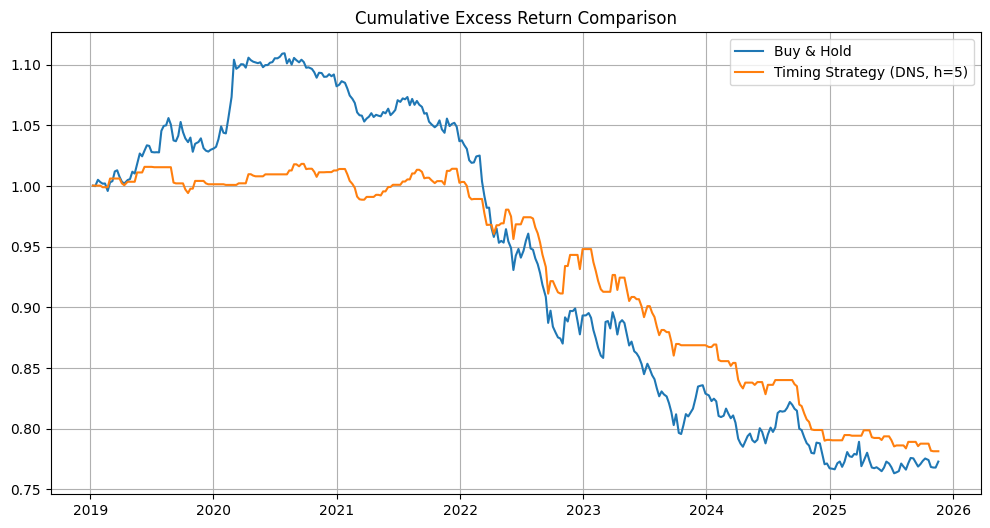

In [15]:
bh_curve = (1 + df_check["BH_ER"]).cumprod()
timing_curve = (1 + df_check["Timing_ER"]).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(bh_curve, label="Buy & Hold")
plt.plot(timing_curve, label=f"Timing Strategy ({model}, h={h})")
plt.title("Cumulative Excess Return Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
print("Merged index:", merged.index.min(), "->", merged.index.max())
print("Prediction index:", predictions[model][("DGS2",h)].index.min(), "->", predictions[model][("DGS2",h)].index.max())
print("Return index:", r_all.index.min(), "->", r_all.index.max())


Merged index: 2009-01-02 00:00:00 -> 2025-11-25 00:00:00
Prediction index: 2019-01-09 00:00:00 -> 2025-11-25 00:00:00
Return index: 2019-01-02 00:00:00 -> 2025-11-18 00:00:00
